# Zadanie rekrutacyjne dla firmy Novomatic
## Autor: Radosław Mocarski

### Dane:
Ze względu na liczne błędy w wersji `.csv` (widoczne m.in. w kolumnie __Supported languages__ oraz w dyskusjach na stronie Kaggle), zdecydowałem się na użycie danych w formacie `.json`, które są rekomendowane przez społeczność, zamiast wersji `.csv` sugerowanej w poleceniu.

## Eksploracja danych:

### Wstępne wczytanie i ogarnięcie

Format danych jest dla mnie zbyt brutalny (mam tylko 16gb ramu w laptopie), więc stworzyłem skrypt `transform_json_to_parquet.py` który bierze pandasem plik json i konwertuje na wydajniejszy format parquet. Próbuje przy okazji rzutować na odpowiednie typy danych (boole, inty, floaty, daty i stringi). Niestety zmieniana jest informacja o listach i nullach w polach tekstowych, ale to opiszę później. Spójrzmy w dane:

In [1]:
import polars as pl
parquet_path = './archive/games.parquet'

print("Wczytywanie pliku Parquet...")
df = pl.read_parquet(parquet_path)

print("\nPodstawowe informacje o zbiorze danych (Schema):")
schema = df.schema
print(schema)

print("\nStatystyki dla kolumn:")
display(df.describe())

Wczytywanie pliku Parquet...

Podstawowe informacje o zbiorze danych (Schema):
Schema({'name': String, 'release_date': Datetime(time_unit='ns', time_zone=None), 'required_age': Int64, 'price': Float64, 'dlc_count': Int64, 'detailed_description': String, 'about_the_game': String, 'short_description': String, 'reviews': String, 'header_image': String, 'website': String, 'support_url': String, 'support_email': String, 'windows': Boolean, 'mac': Boolean, 'linux': Boolean, 'metacritic_score': Int64, 'metacritic_url': String, 'achievements': Int64, 'recommendations': Int64, 'notes': String, 'supported_languages': List(String), 'full_audio_languages': List(String), 'packages': String, 'developers': List(String), 'publishers': List(String), 'categories': List(String), 'genres': List(String), 'screenshots': List(String), 'movies': Float64, 'user_score': Int64, 'score_rank': Float64, 'positive': Int64, 'negative': Int64, 'estimated_owners': String, 'average_playtime_forever': Int64, 'average_pla

statistic,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,__index_level_0__
str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,str,f64
"""count""","""122610""","""122611""",122611.0,122611.0,122611.0,"""114191""","""114162""","""114302""","""12070""","""122530""","""49676""","""54192""","""100364""",122611.0,122611.0,122611.0,122611.0,"""4256""",122611.0,122611.0,"""22458""",114231.0,49881.0,"""96799""",114180.0,113784.0,113658.0,114198.0,116593.0,0.0,122611.0,40.0,122611.0,122611.0,"""122611""",122611.0,122611.0,122611.0,122611.0,122611.0,122611.0,"""83346""",122611.0
"""null_count""","""1""","""0""",0.0,0.0,0.0,"""8420""","""8449""","""8309""","""110541""","""81""","""72935""","""68419""","""22247""",0.0,0.0,0.0,0.0,"""118355""",0.0,0.0,"""100153""",8380.0,72730.0,"""25812""",8431.0,8827.0,8953.0,8413.0,6018.0,122611.0,0.0,122571.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""39265""",0.0
"""mean""",null,"""2022-01-21 08:27:37.847990""",0.167611,4.765091,0.545856,null,null,null,null,null,null,null,null,0.999641,0.173655,0.128096,2.564941,null,18.087015,961.824967,null,null,null,null,null,null,null,null,null,null,0.024549,99.175,1044.986135,169.197429,null,208.02322,13.789268,173.570528,14.72217,18.353663,54.593324,null,1.9854e6
"""std""",null,null,1.653591,12.53103,14.516026,null,null,null,null,null,null,null,null,null,null,null,13.660559,null,141.493879,21878.803992,null,null,null,null,null,null,null,null,null,null,1.394901,0.675107,28091.729937,5374.64488,null,11217.684738,270.378053,11202.537481,294.509615,28.85897,3729.451567,null,1.0876e6
"""min""","""! Shakabula *""","""1997-06-30 00:00:00""",0.0,0.0,0.0,"""! ! ! PLEASE READ BEFORE BUYIN…","""! Important: 'X' key for selec…","""Hungry piggy vs Chicken: Yes…","""""ACDSee 15 is a full-featured …","""https://shared.akamai.steamsta…","""GranVitreous.com""","""*""","""*""",0.0,0.0,0.0,0.0,"""http://www.metacritic.com/game…",0.0,0.0,"""!! Important Notice !! This ga…",null,null,"""[{'title': ""Buy '1st Core: The…",null,null,null,null,null,null,0.0,98.0,0.0,0.0,"""0 - 0""",0.0,0.0,0.0,0.0,0.0,0.0,"""{""1990's"": 119, 'MMORPG': 112,…",10.0
"""25%""",null,"""2019-12-20 00:00:00""",0.0,0.55,0.0,null,null,null,null,null,null,null,null,null,null,null,0.0,null,0.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,99.0,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,null,1.06319e6
"""50%""",null,"""2022-11-15 00:00:00""",0.0,2.24,0.0,null,null,null,null,null,null,null,null,null,null,null,0.0,null,2.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,99.0,5.0,1.0,null,0.0,0.0,0.0,0.0,0.0,0.0,null,1.90738e6
"""75%""",null,"""2024-10-04 00:00:00""",0.0,5.24,0.0,null,null,null,null,null,null,null,null,null,null,null,0.0,null,19.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,100.0,37.0,10.0,null,0.0,0.0,0.0,0.0,40.0,0.0,null,2.86959e6
"""max""","""𣸩""","""2026-01-05 00:00:00""",21.0,999.98,3703.0,"""🫧 A Whimsical Bubble-Popping A…","""🫧 A Whimsical Bubble-Popping A…","""🩸🌌💀🌫️⛪️""","""게임 분위기 – 어둡고 무서운 사운드로 인해 긴장감을 …","""https://shared.akamai.steamsta…","""www.windybeard.com""","""暂无""","""𝗰𝗵𝗶𝗰𝗮𝗴𝗼𝗽𝗿𝗼𝗷𝗲𝗰𝘁@𝟭𝟲𝟯.𝗰𝗼𝗺""",1.0,1.0,1.0,97.0,"""https://www.metacritic.com/gam…",9821.0,4.830455e6,"""🪀 CONTENT WARNINGS 🪀 TOY BOX c…",null,null,"""[{'title': 'Yearly Subscriptio…",null,null,null,null,null,null,100.0,100.0,7.642084e6,1.173003e6,"""50000000 - 100000000""",3.429544e6,20088.0,3.429544e6,2008

In [2]:
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(1000)
print(df.head(3))

shape: (3, 43)
┌─────────────────────────────────┬─────────────────────┬──────────────┬───────┬───────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬────────────────────────┬─────────┬───────┬───────┬──────────────────┬────────────────┬──────────────┬─────────────────┬───────┬─────────────────────────────────┬──────────────────────┬─────────────────────────────────┬─────────────────┬────────────────┬─────────────────────────────────┬───────────────┬─────────────────────────────────┬────────┬────────────┬────────────┬──────────┬──────────┬──────────────────┬──────────────────────────┬─────────────────────────┬─────────────────────────┬────────────────────────┬──────────┬──────────┬─────────────────────────────────┬───────────────────┐
│ name                            ┆ release_date        ┆ required_age ┆ price ┆ dlc

Niestety można zauważyć, że w polach tekstowych jest masa elementów pustych (o treści `""` lub `"[]"`) i nie ma żadnej pustej, więc wypada je zmienić na wartości `null`. Same listy zostały potraktowane jako tekst, a jego elementy są w klamrach, więc i to wypada zmienić.

In [3]:
list_columns = [
    'supported_languages', 'full_audio_languages', 'developers', 
    'publishers', 'categories', 'genres', 'screenshots'
]

needs_cleaning = False
if 'categories' in schema and schema['categories'] == pl.String:
    needs_cleaning = True

if needs_cleaning:
    string_columns = [col for col, dtype in schema.items() if dtype == pl.String]
    null_cleaning_exprs = []
    
    for col_name in string_columns:
        null_cleaning_exprs.append(
            pl.when(pl.col(col_name).str.strip_chars().is_in(["", "[]", "{}", "null", "None", "NaN"]))
            .then(None)
            .otherwise(pl.col(col_name))
            .alias(col_name)
        )
    
    df = df.with_columns(null_cleaning_exprs)
    
    list_conversion_exprs = []
    for col_name in list_columns:
        if col_name in schema:
            list_conversion_exprs.append(
                pl.col(col_name)
                .str.strip_chars("[]") 
                .str.split(", ")       
                .list.eval(            
                    pl.element().str.strip_chars("'\" ") 
                )
                .alias(col_name)
            )
            
    df = df.with_columns(list_conversion_exprs)
    df.write_parquet(parquet_path)

else:
    print("Plik jest już wyczyszczony! Posiada poprawne listy i nulle. Pomijam czyszczenie.")

print("\nObecny schemat (wyrywkowe kolumny):")
preview_columns = ['categories', 'developers', 'supported_languages', 'tags']
for col_name in preview_columns:
    if col_name in df.schema:
        print(f" - {col_name}: {df.schema[col_name]}")

Plik jest już wyczyszczony! Posiada poprawne listy i nulle. Pomijam czyszczenie.

Obecny schemat (wyrywkowe kolumny):
 - categories: List(String)
 - developers: List(String)
 - supported_languages: List(String)
 - tags: String


In [4]:
print("Statystyki dla kolumn:")
display(df.describe())

Statystyki dla kolumn:


statistic,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,__index_level_0__
str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,f64,f64,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,str,f64
"""count""","""122610""","""122611""",122611.0,122611.0,122611.0,"""114191""","""114162""","""114302""","""12070""","""122530""","""49676""","""54192""","""100364""",122611.0,122611.0,122611.0,122611.0,"""4256""",122611.0,122611.0,"""22458""",114231.0,49881.0,"""96799""",114180.0,113784.0,113658.0,114198.0,116593.0,0.0,122611.0,40.0,122611.0,122611.0,"""122611""",122611.0,122611.0,122611.0,122611.0,122611.0,122611.0,"""83346""",122611.0
"""null_count""","""1""","""0""",0.0,0.0,0.0,"""8420""","""8449""","""8309""","""110541""","""81""","""72935""","""68419""","""22247""",0.0,0.0,0.0,0.0,"""118355""",0.0,0.0,"""100153""",8380.0,72730.0,"""25812""",8431.0,8827.0,8953.0,8413.0,6018.0,122611.0,0.0,122571.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""39265""",0.0
"""mean""",null,"""2022-01-21 08:27:37.847990""",0.167611,4.765091,0.545856,null,null,null,null,null,null,null,null,0.999641,0.173655,0.128096,2.564941,null,18.087015,961.824967,null,null,null,null,null,null,null,null,null,null,0.024549,99.175,1044.986135,169.197429,null,208.02322,13.789268,173.570528,14.72217,18.353663,54.593324,null,1.9854e6
"""std""",null,null,1.653591,12.53103,14.516026,null,null,null,null,null,null,null,null,null,null,null,13.660559,null,141.493879,21878.803992,null,null,null,null,null,null,null,null,null,null,1.394901,0.675107,28091.729937,5374.64488,null,11217.684738,270.378053,11202.537481,294.509615,28.85897,3729.451567,null,1.0876e6
"""min""","""! Shakabula *""","""1997-06-30 00:00:00""",0.0,0.0,0.0,"""! ! ! PLEASE READ BEFORE BUYIN…","""! Important: 'X' key for selec…","""Hungry piggy vs Chicken: Yes…","""""ACDSee 15 is a full-featured …","""https://shared.akamai.steamsta…","""GranVitreous.com""","""*""","""*""",0.0,0.0,0.0,0.0,"""http://www.metacritic.com/game…",0.0,0.0,"""!! Important Notice !! This ga…",null,null,"""[{'title': ""Buy '1st Core: The…",null,null,null,null,null,null,0.0,98.0,0.0,0.0,"""0 - 0""",0.0,0.0,0.0,0.0,0.0,0.0,"""{""1990's"": 119, 'MMORPG': 112,…",10.0
"""25%""",null,"""2019-12-20 00:00:00""",0.0,0.55,0.0,null,null,null,null,null,null,null,null,null,null,null,0.0,null,0.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,99.0,0.0,0.0,null,0.0,0.0,0.0,0.0,0.0,0.0,null,1.06319e6
"""50%""",null,"""2022-11-15 00:00:00""",0.0,2.24,0.0,null,null,null,null,null,null,null,null,null,null,null,0.0,null,2.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,99.0,5.0,1.0,null,0.0,0.0,0.0,0.0,0.0,0.0,null,1.90738e6
"""75%""",null,"""2024-10-04 00:00:00""",0.0,5.24,0.0,null,null,null,null,null,null,null,null,null,null,null,0.0,null,19.0,0.0,null,null,null,null,null,null,null,null,null,null,0.0,100.0,37.0,10.0,null,0.0,0.0,0.0,0.0,40.0,0.0,null,2.86959e6
"""max""","""𣸩""","""2026-01-05 00:00:00""",21.0,999.98,3703.0,"""🫧 A Whimsical Bubble-Popping A…","""🫧 A Whimsical Bubble-Popping A…","""🩸🌌💀🌫️⛪️""","""게임 분위기 – 어둡고 무서운 사운드로 인해 긴장감을 …","""https://shared.akamai.steamsta…","""www.windybeard.com""","""暂无""","""𝗰𝗵𝗶𝗰𝗮𝗴𝗼𝗽𝗿𝗼𝗷𝗲𝗰𝘁@𝟭𝟲𝟯.𝗰𝗼𝗺""",1.0,1.0,1.0,97.0,"""https://www.metacritic.com/gam…",9821.0,4.830455e6,"""🪀 CONTENT WARNINGS 🪀 TOY BOX c…",null,null,"""[{'title': 'Yearly Subscriptio…",null,null,null,null,null,null,100.0,100.0,7.642084e6,1.173003e6,"""50000000 - 100000000""",3.429544e6,20088.0,3.429544e6,2008

In [5]:
print(df.head(3))

shape: (3, 43)
┌─────────────────────────────────┬─────────────────────┬──────────────┬───────┬───────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬─────────┬─────────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┬────────────────────────┬─────────┬───────┬───────┬──────────────────┬────────────────┬──────────────┬─────────────────┬───────┬─────────────────────────────────┬──────────────────────┬─────────────────────────────────┬─────────────────┬────────────────┬─────────────────────────────────┬───────────────┬─────────────────────────────────┬────────┬────────────┬────────────┬──────────┬──────────┬──────────────────┬──────────────────────────┬─────────────────────────┬─────────────────────────┬────────────────────────┬──────────┬──────────┬─────────────────────────────────┬───────────────────┐
│ name                            ┆ release_date        ┆ required_age ┆ price ┆ dlc

Jak widać, nulle się pojawiły i to nawet niekiedy liczne. Nie zmieniłem do końca dwóch kolumn, mianowicie __tags__ i __packages__ przez ich ciężką późniejszą analizę. 

### Kolumny Tags i Packages

Tagi są słownikiem z popularnością kategorii gry nadawaną przez użytkowników - im większa liczba przy tagu, tym więcej użytkowników zaklasyfikowało tą grę pod ten tag. 

Paczki są dużo bardziej złożonym tematem, ponieważ są to oferty handlowe różnych pakietów. Np gry z jakąś dodatkową zawartością. Jest to niezwykle trudna kolumna do rozpakowania, ponieważ jest to fragment kodu JSONa zrzucony na string... Dlatego zagłębię się w te dane głębiej. Najpierw wyświetlę jeden rekord, a potem ten najdłuższy z zestawu danych.

In [6]:
print(df.get_column("packages")[13])

[{'title': 'Buy Forests, Fields and Fortresses', 'description': '', 'subs': [{'text': 'Forests, Fields and Fortresses - $4.99 $1.49', 'description': '', 'price': 1.49}]}]


In [7]:
longest_text = (
    df.select(pl.col("packages"))
    .filter(pl.col("packages").is_not_null())
    .with_columns(leng=pl.col("packages").str.len_chars())
    .sort("leng", descending=True)
    .head(1)
    .get_column("packages")[0]
)

print(f"Długość tekstu: {len(longest_text)} znaków")
print(longest_text)

Długość tekstu: 2205 znaków
[{'title': 'Buy Battlefield™ 6', 'description': '', 'subs': [{'text': 'Battlefield™ 6 - $69.99 $48.99', 'description': '', 'price': 48.99}, {'text': 'Battlefield™ 6 Phantom Edition - $99.99 $79.99', 'description': '', 'price': 79.99}]}, {'title': 'Buy Battlefield Coins', 'description': 'Battlefield Coins can be used in the in-game Store to purchase Soldiers, Weapon Packages, Vehicle Skins, and a host of other cosmetic accessories and boosters. Can also be used to purchase the Battle Pass. Click HERE for more information.', 'subs': [{'text': '500 BFC for Battlefield™ 6 and REDSEC - $4.99', 'description': 'Battlefield Coins can be used in the in-game Store to purchase Soldiers, Weapon Packages, Vehicle Skins, and a host of other cosmetic accessories and boosters. Can also be used to purchase the Battle Pass. Click HERE for more information.', 'price': 4.99}, {'text': '1100 BFC for Battlefield™ 6 and REDSEC - $9.99', 'description': 'Battlefield Coins can be use

Informacje z tej kolumny wydają się dosyć cenne. Jeżeli twórcy gry zależy na robieniu licznych pakietów, to może mu nieco bardziej zależeć na tej grze, przez co np. bardziej ją dopracował czy też zwiększył nakłady na marketing. Jednocześnie może wskazywać na nachalność mikrotransakcji, podejściu do ucinania zawartości i sprzedaży w dodatkach itp. Szkoda byłoby zatracić tą informację, dlatego spróbuję ją jakoś później przetworzyć.

Chyba najracjonalniejszym podejściem będzie analiza tekstu w poszukiwaniu konkretnego ciągu znaków. Obserwuję tutaj dwie interesujące opcje:
- `{'title': `
- `, 'price': `

Są na tyle unikatowe, że nie powinny znajdować się w opisach gier, a jednocześnie jednoznacznie definiują pojedynczy niepowtarzalny element. Na przykładzie gry Battlefield wylistowanym powyżej, można stwierdzić, że wyszukiwanie pierwszego ciągu będzie definiowało liczbę wersji gry, natomiast drugiego powiększy dodatkowo o mini dodatki do gry jak np. płatna waluta w grze. 

Przyznam szczerze, że nie wiem czy oddzielanie tych informacji ma jakiś większy sens. Obie te informacje wskazują na podobny aspekt i raczej głównym elementem będzie informacja, czy twórca robi więcej niż jedną ofertę. A że zazwyczaj staram się minimalizować liczbę parametrów branych do modeli, to wydaje mi się, że zastosowanie selekcji po drugim ciągu będzie najlepsze (ponieważ zawiera jednocześnie informację o pierwszym).

In [8]:
df = df.with_columns(
    pl.col("packages")
    .str.count_matches(r", 'price': ")
    .fill_null(0)
    .cast(pl.Int32)
    .alias("packages")
)

print(df.select(["packages"]).describe())

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ packages │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 122611.0 │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.840773 │
│ std        ┆ 0.516906 │
│ min        ┆ 0.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 1.0      │
│ 75%        ┆ 1.0      │
│ max        ┆ 17.0     │
└────────────┴──────────┘


Kolumna tagów jest dużo prostsza. Przez to że jest słownikiem zrzutowanym do tekstu, można łatwo wydobyć potrzebne informacje. Niewątpliwie kategorie gry (jakimi są tagi) taką informacją są. Podejść do zmiany tych danych na przystępne do analizy danych jest kilka. Jedną z popularnych metod jest stworzenie kolumn z każdą kategorią i jako one-hot encoding zaznaczać czy do niej należy czy też nie. Zbliżoną wersją jest zamiast stosowania booli użyć np int64 i przepisac te dane ze słownika tworząc macierz rzadką (sparse matrix). 

Problemem w tych podejściach jest to, że dataframe staje się dla użytkownika małoczytelny przez liczbę kolumn (choć te obecnie już są małoczytelne przez ich liczbę). Zachowuje się wtedy pełną informację o danych, lub znaczną ich część (w przypadku podejścia boolowego). Z tego też powodu, często stosuje się podejście wypisania jednej (lub kilku) najważniejszych kategorii, zostawienie ich w dataframe w formie tekstowej (kategorycznej), a później zastosowanie odpowiedniej biblioteki, która zrobi operacje dzielenia na boole tuż przed uczeniem maszynowym. Dzięki temu my widzimy czytelne dane, a komputer ma dla niego wygodniejszą formę danych.

Dlatego, żeby sprawdzić jak dużym problemem będzie podział na kategorie z intami/boolami w dataframe, zobaczmy ile unikatowych danych by było.

In [9]:
df_tags = df.select(
    pl.col("tags")
    .str.extract_all(r"['\"]([^'\"]+)['\"]:")
    .list.eval(pl.element().str.strip_chars("'\""))
    .alias("tag_list")
)

all_tags_count = df_tags.select(
    pl.col("tag_list").explode().drop_nulls().n_unique()
).item()

top1_tag_count = df_tags.select(
    pl.col("tag_list").list.first().drop_nulls().n_unique()
).item()

top2_tag_count = df_tags.select(
    pl.col("tag_list").list.slice(1, 1).list.first().drop_nulls().n_unique()
).item()

print(f"1. Laczna liczba wszystkich unikalnych tagow na Steam: {all_tags_count}")
print(f"2. Liczba unikalnych tagow, jesli wezmiemy tylko 1. miejsce: {top1_tag_count}")
print(f"3. Liczba unikalnych tagow, jesli wezmiemy tylko 2. miejsce: {top2_tag_count}")

dimensionality_reduction = (1 - (top1_tag_count / all_tags_count)) * 100
print(f"\nWNIOSEK: Biorac tylko glowny tag, redukujemy wymiarowosc danych o ok. {dimensionality_reduction:.1f}%.")

1. Laczna liczba wszystkich unikalnych tagow na Steam: 452
2. Liczba unikalnych tagow, jesli wezmiemy tylko 1. miejsce: 419
3. Liczba unikalnych tagow, jesli wezmiemy tylko 2. miejsce: 434

WNIOSEK: Biorac tylko glowny tag, redukujemy wymiarowosc danych o ok. 7.3%.


Szybka weryfikacja tagów po zastosowanym regexie

In [10]:
print(df_tags.select(
    pl.col("tag_list").explode().drop_nulls().unique()
).head(10))

shape: (10, 1)
┌─────────────────────────────────┐
│ tag_list                        │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ America':                       │
│ Intentionally Awkward Controls… │
│ Survival':                      │
│ Wholesome':                     │
│ Addictive':                     │
│ Martial Arts':                  │
│ Villain Protagonist':           │
│ Nudity':                        │
│ Music-Based Procedural Generat… │
│ Artificial Intelligence':       │
└─────────────────────────────────┘


In [11]:
print(df_tags.select(
    pl.col("tag_list").list.slice(1, 1).list.first().drop_nulls().unique()
).head(10))

shape: (10, 1)
┌─────────────────────────┐
│ tag_list                │
│ ---                     │
│ str                     │
╞═════════════════════════╡
│ Surreal':               │
│ Conspiracy':            │
│ Fishing':               │
│ Linear':                │
│ Parody ':               │
│ Visual Novel':          │
│ Gun Customization':     │
│ Documentary':           │
│ Nature':                │
│ Massively Multiplayer': │
└─────────────────────────┘


Nie jest perfekcyjnie, bo zostaje zamknięcie cudzysłowiu i dwukropek, ale nie będzie generować błędów.

Wracając do meritum, jeżeli zrobię klasyfikację tylko czy dany tag jest pierwszym tagiem w tej grze oszczędzi mi ok 7% wymiarów, natomiast zrobienie oddzielnie tagu 1 od 2 zwiększa mi już drastycznie liczbę wymiarów. Więc to nie ma sensu. Można zrobić po prostu klasyfikację czy jest ten tag czy nie i zachować 452 wymiary. Szczególnie, że ułatwi to później dzielenie zbioru danych na treningowy i testowy przez zmniejszenie ryzyka braku konkretnego tagu w danych treningowych. Warto wtedy byłoby zastosować kryterium, że musi być minimum x głosów za jakimś tagiem, żeby wyeliminować losowe kliknięcia przydzielające tag.

Ostatecznie jednak zrezygnuję z tych metod i zastąpię ją prostą zmienną liczącą liczbę tagów przypisaną do danej gry. Wątpię, żeby to była decydująca zmienna, mocno zmniejszy czytelność datasetu i strasznie zwiększy wymiarowość modelu. Widząc późniejszą analizę, będzie sporo danych odstających, więc tradycyjne MLP może być kiepskie, więc bardziej nastawiam się na drzewa decyzyjne jak XGBoost. Z tego powodu, tak drastyczne zwiększenie liczby wymiarów byłoby tylko obliczeniożerne, a ponieważ żadna z tych cech nie byłaby raczej na tyle istotna, żeby byłą wysoko w hierarhii drzew to obecność tych parametrów nie będzie miała wpływu na wynik.

In [12]:
df = df.with_columns(
    pl.col("tags")
    .str.extract_all(r"['\"]([^'\"]+)['\"]:")
    .list.len()
    .fill_null(0)
    .cast(pl.Int32)
    .alias("tags")
)

print(df.select(["name", "tags"]).head(5))

shape: (5, 2)
┌─────────────────────────────────┬──────┐
│ name                            ┆ tags │
│ ---                             ┆ ---  │
│ str                             ┆ i32  │
╞═════════════════════════════════╪══════╡
│ Black Dragon Mage Playtest      ┆ 0    │
│ Supipara - Chapter 1 Spring Ha… ┆ 4    │
│ Mystery Solitaire The Black Ra… ┆ 16   │
│ 버튜버 파라노이아 - Vtuber      ┆ 0    │
│ Paranoia                        ┆      │
│ Maze Quest VR                   ┆ 0    │
└─────────────────────────────────┴──────┘


### Kolumny liczbowe

Ze względu na gigantyczną liczbę kolumn, trzeba je jakoś masowo posprawdzać czy mają sens i potrzebę istnienia. Jednak zanim przejdziemy do czystek, sprawdźmy jakie kolumny są liczbowe:

In [13]:
import polars.selectors as cs

numeric_cols = df.select(cs.numeric()).describe()
print("Kolumny liczbowe:")
print(numeric_cols)

Kolumny liczbowe:
shape: (9, 21)
┌────────────┬──────────────┬──────────┬───────────┬──────────────────┬──────────────┬─────────────────┬──────────┬──────────┬────────────┬────────────┬──────────────┬────────────┬──────────────────────────┬─────────────────────────┬─────────────────────────┬────────────────────────┬───────────┬─────────────┬──────────┬───────────────────┐
│ statistic  ┆ required_age ┆ price    ┆ dlc_count ┆ metacritic_score ┆ achievements ┆ recommendations ┆ packages ┆ movies   ┆ user_score ┆ score_rank ┆ positive     ┆ negative   ┆ average_playtime_forever ┆ average_playtime_2weeks ┆ median_playtime_forever ┆ median_playtime_2weeks ┆ discount  ┆ peak_ccu    ┆ tags     ┆ __index_level_0__ │
│ ---        ┆ ---          ┆ ---      ┆ ---       ┆ ---              ┆ ---          ┆ ---             ┆ ---      ┆ ---      ┆ ---        ┆ ---        ┆ ---          ┆ ---        ┆ ---                      ┆ ---                     ┆ ---                     ┆ ---                    

Od razu rzuca się w oczy fakt, że kolumna __movies__ jest cała pusta. Podejrzewam, że twórca datasetu miał jakiś błąd podczas scrapowania, więc tą kolumnę trzeba usunąć. Kolumna __score_rank__ również jest prawie całkowicie pusta. Ma jedynie 40 rekordów niepustych, choć to akurat w wyniku działania samej platformy steam, ponieważ liczy tą metrykę tylko dla najpopularniejszych gier. Oznacza to, że muszę również tą kolumnę usunąć do kolejnych działań, żeby później nie zepsuć sobie modeli predykcji czy jakaś gra będzie hitem. Model szybko by się zbiasował i byłby gorszy.

In [14]:
df = df.drop(["movies", "score_rank"])

Dodatkowo, widać w danych playtime, że niektóre gry mają średnią i medianę czasu wynoszącą 20 088 minut. Jest to technicznie możliwe (2 tygodnie mają 20 160 minut), ale oznacza, że co najmniej połowa graczy to boty działające non stop lub ludzie zostawiają grę włączoną i w praktyce w nią nie grają przez większość tego czasu. Zobaczmy jak wyglądają te kolumny.

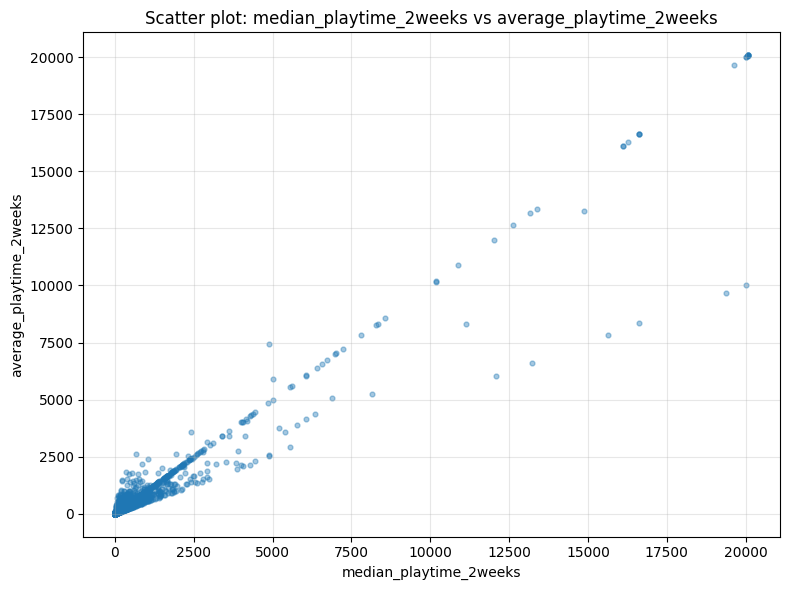

In [15]:
import matplotlib.pyplot as plt

plot_df = (
    df.select(["median_playtime_2weeks", "average_playtime_2weeks"])
      .drop_nulls()
)

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["median_playtime_2weeks"].to_numpy(),
    plot_df["average_playtime_2weeks"].to_numpy(),
    alpha=0.4,
    s=12
)

plt.title("Scatter plot: median_playtime_2weeks vs average_playtime_2weeks")
plt.xlabel("median_playtime_2weeks")
plt.ylabel("average_playtime_2weeks")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

zazwyczaj do outlierów stosuje się wykres pudełkowy, ale w tym przypadku 75% gier ma wynik równy zero, dlatego w tym przypadku nie ma sensu czyste narysowanie. Jednak zobaczmy takie wykresy dla przypadków niezerowych.

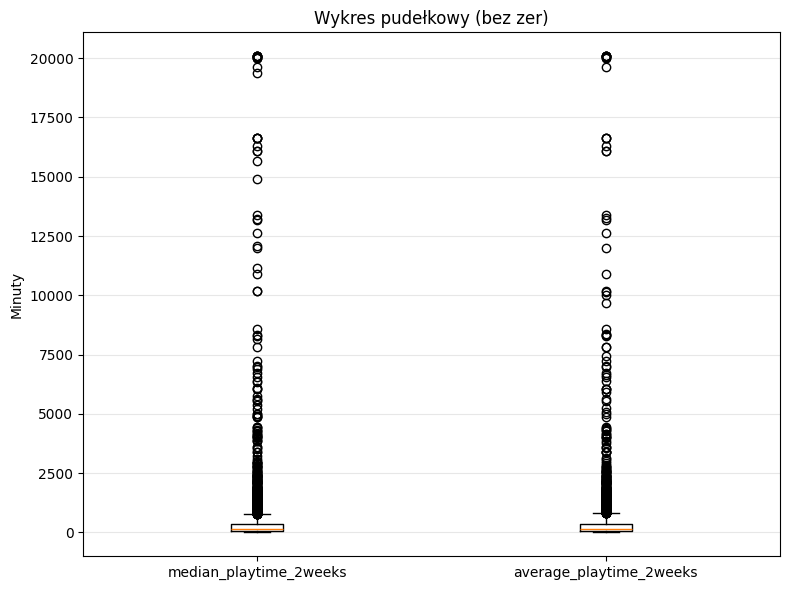

In [16]:
box_df = (
    df.select(["median_playtime_2weeks", "average_playtime_2weeks"])
      .drop_nulls()
      .filter(
          (pl.col("median_playtime_2weeks") > 0) &
          (pl.col("average_playtime_2weeks") > 0)
      )
)

plt.figure(figsize=(8, 6))
plt.boxplot(
    [
        box_df["median_playtime_2weeks"].to_numpy(),
        box_df["average_playtime_2weeks"].to_numpy()
    ],
    tick_labels=["median_playtime_2weeks", "average_playtime_2weeks"],
    showfliers=True
)

plt.title("Wykres pudełkowy (bez zer)")
plt.ylabel("Minuty")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Niestety uderza tutaj problem rozkładu danych... I nie tylko w tych zmiennych. Rozkłady pozostałych kolumn też będą raczej tak niewdzięczne. Gigantyczna liczba zer i liczb bliskich zeru, a niewielka liczba wartości większych. Rozkłady wyglądają na potrzebujące normalizacji logarytmicznej (log1p), ponieważ uznanie tych wartości za odstające spowoduje usunięcie popularnych gier i z 4% hitów, nie zostanie żaden.

Wyjątkiem jest kolumna __index_level_0__, ale ona jest trzymana wyłącznie dla posiadania porządku wierszy. Oczywiście nie będzie brana do modeli ML.

Żeby zweryfikować moją tezę, sprawdzę procenty 0 w kolumnach, skośność i percentyle 95/99/99.9.

In [17]:
numeric_cols = [c for c in df.select(cs.numeric()).columns if c != "__index_level_0__"]

rows = []
for col in numeric_cols:
    s = df.get_column(col).drop_nulls()
    n = s.len()

    if n == 0:
        rows.append({
            "column": col,
            "zero_pct": None,
            "variance": None,
            "skewness": None,
            "normalized_skewness": None,
            "strength": None,
            "p95": None,
            "p99": None,
            "p999": None,
        })
        continue

    raw_skew = s.skew()
    raw_var = s.var()
    
    if n > 2:
        se_skew = (6 * n / ((n + 1) * (n - 2))) ** 0.5
        normalized_skew = raw_skew / se_skew if se_skew > 0 else None
        
        strength = (
            "silna" if abs(normalized_skew or 0) > 2 else
            "umiarkowana" if abs(normalized_skew or 0) > 1 else
            "słaba"
        )
    else:
        normalized_skew = None
        strength = None

    rows.append({
        "column": col,
        "zero_pct": float(((s == 0).sum() / n) * 100),
        "variance": float(raw_var) if raw_var is not None else None,
        "skewness": float(raw_skew),
        "normalized_skewness": float(normalized_skew) if normalized_skew is not None else None,
        "strength": strength,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
    })

stats_numeric = (
    pl.DataFrame(rows)
    .sort("zero_pct", descending=True)
)

stats_transposed = (
    stats_numeric
    .select(["column", "zero_pct", "variance", "skewness", "normalized_skewness", "strength", "p95", "p99", "p999"])
    .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
    .pivot(
        values="wartosc",
        index="statystyka",
        columns="column",
    )
)

print("Statystyki kolumn liczbowych (w tym wariancja):")
display(stats_transposed)

Statystyki kolumn liczbowych (w tym wariancja):


/tmp/ipykernel_509128/3635479277.py:58: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
/tmp/ipykernel_509128/3635479277.py:59: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


statystyka,user_score,required_age,average_playtime_2weeks,median_playtime_2weeks,metacritic_score,dlc_count,peak_ccu,recommendations,average_playtime_forever,median_playtime_forever,discount,achievements,negative,positive,tags,price,packages
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""zero_pct""","""99.96737649966153""","""98.9625726892367""","""96.82083989201622""","""96.82083989201622""","""96.52885956398691""","""85.50619438712677""","""83.9525001835072""","""82.94932754809928""","""78.69766986648833""","""78.69766986648833""","""66.82108456826874""","""48.586179054081605""","""45.016352529544655""","""34.476515157693846""","""32.02404351974945""","""21.373286246747845""","""21.05194476841393"""
"""variance""","""1.945747548781878""","""2.7343643939927986""","""73104.29146985973""","""86735.91324300616""","""186.61087722086629""","""210.71500629922468""","""13908808.993988214""","""478682064.1009102""","""125836450.8720082""","""125496846.01839045""","""832.8401362219115""","""20020.517809612862""","""28886807.590896554""","""789145290.83713""","""70.67895631574082""","""157.0267109440883""","""0.26719197752765256"""
"""skewness""","""59.247222418212225""","""9.88250787659473""","""51.67735510717005""","""48.909423184288144""","""5.227040296865478""","""171.82522857624858""","""209.95054542494844""","""113.90751988849478""","""262.89454994846693""","""263.989690453353""","""1.220366072239265""","""32.63067133595936""","""156.86321127224608""","""177.8417009705343""","""0.07678834273254508""","""22.403649008755664""","""1.3534326197817155"""
"""normalized_skewness""","""8469.452094992803""","""1412.7147843048829""","""7387.33168597569""","""6991.652937399564""","""747.210849487701""","""24562.59521949144""","""30012.6489347054""","""16283.198495706916""","""37581.04947277324""","""37737.600947506464""","""174.4525998911269""","""4664.588421657554""","""22423.759277002606""","""25422.65620875709""","""10.976973496520642""","""3202.6249381500484""","""193.47460132609092"""
"""strength""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna"""
"""p95""","""0.0""","""0.0""","""0.0""","""0.0""","""0.0""","""2.0""","""9.0""","""1071.0""","""492.0""","""406.0""","""80.0""","""55.0""","""226.0""","""1091.0""","""20.0""","""14.99""","""1.0"""
"""p99""","""0.0""","""12.0""","""266.0""","""261.0""","""80.0""","""7.0""","""224.0""","""12500.0""","""2276.0""","""1593.0""","""90.0""","""100.0""","""2146.0""","""13165.0""","""20.0""","""29.99""","""2.0"""
"""p999""","""0.0""","""18.0""","""1946.0""","""2173.0""","""89.0""","""50.0""","""7073.0""","""143405.0""","""16998.0""","""11101.0""","""95.0""","""1552.0""","""22098.0""","""154122.0""","""20.0""","""199.99""","""4.0"""


Jak widać, dane są bardzo mocno skośne. Co więcej, kolumna __user_scoore__ jest praktycznie cała zerowa. Po analizie dostępnych informacji, kolumna ta opiera się na danych, które są archaiczne i niewspierane od dłuższego czasu. Steam nie gwarantuje jakości tych danych, a więc żeby nie karmić modelu bezwartościowymi danymi i tą kolumnę usuwam.

In [18]:
df = df.drop(["user_score"])

Przeprowadźmy wcześniej wspomnianą normalizację log1p na wszystkich pozostałych kolumnach liczbowych (z wyjątkiem index_level_0 i tags, ponieważ taka normalizacja pogarsza znacząco skośność).

In [19]:
numeric_cols = [c for c in df.select(cs.numeric()).columns if (c != "__index_level_0__" and c != "tags")]

mins = df.select([pl.col(c).min().alias(c) for c in numeric_cols]).to_dicts()[0]
invalid_cols = [c for c, v in mins.items() if v is not None and v <= -1]

if invalid_cols:
    print("Nie można zastosować log1p dla kolumn (mają wartości <= -1):", invalid_cols)
else:
    df = df.with_columns([
        pl.col(c).cast(pl.Float64).log1p().alias(c)
        for c in numeric_cols
    ])
    print(f"Zastosowano log1p do {len(numeric_cols)} kolumn liczbowych.")


Zastosowano log1p do 15 kolumn liczbowych.


In [20]:
rows = []
for col in numeric_cols:
    s = df.get_column(col).drop_nulls()
    n = s.len()

    if n == 0:
        rows.append({
            "column": col,
            "zero_pct": None,
            "variance": None,
            "skewness": None,
            "normalized_skewness": None,
            "strength": None,
            "p95": None,
            "p99": None,
            "p999": None,
        })
        continue

    raw_skew = s.skew()
    raw_var = s.var()
    
    if n > 2:
        se_skew = (6 * n / ((n + 1) * (n - 2))) ** 0.5
        normalized_skew = raw_skew / se_skew if se_skew > 0 else None
        
        strength = (
            "silna" if abs(normalized_skew or 0) > 2 else
            "umiarkowana" if abs(normalized_skew or 0) > 1 else
            "słaba"
        )
    else:
        normalized_skew = None
        strength = None

    rows.append({
        "column": col,
        "zero_pct": float(((s == 0).sum() / n) * 100),
        "variance": float(raw_var) if raw_var is not None else None,
        "skewness": float(raw_skew),
        "normalized_skewness": float(normalized_skew) if normalized_skew is not None else None,
        "strength": strength,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
    })

stats_numeric = (
    pl.DataFrame(rows)
    .sort("zero_pct", descending=True)
)

stats_transposed = (
    stats_numeric
    .select(["column", "zero_pct", "variance", "skewness", "normalized_skewness", "strength", "p95", "p99", "p999"])
    .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
    .pivot(
        values="wartosc",
        index="statystyka",
        columns="column",
    )
)

print("Statystyki kolumn liczbowych (w tym wariancja):")
display(stats_transposed)

Statystyki kolumn liczbowych (w tym wariancja):


/tmp/ipykernel_509128/1575301391.py:56: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
/tmp/ipykernel_509128/1575301391.py:57: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


statystyka,required_age,average_playtime_2weeks,median_playtime_2weeks,metacritic_score,dlc_count,peak_ccu,recommendations,average_playtime_forever,median_playtime_forever,discount,achievements,negative,positive,price,packages
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""zero_pct""","""98.9625726892367""","""96.82083989201622""","""96.82083989201622""","""96.52885956398691""","""85.50619438712677""","""83.9525001835072""","""82.94932754809928""","""78.69766986648833""","""78.69766986648833""","""66.82108456826874""","""48.586179054081605""","""45.016352529544655""","""34.476515157693846""","""21.373286246747845""","""21.05194476841393"""
"""variance""","""0.08252251950244843""","""0.7660612755146189""","""0.77159572295542""","""0.6218400674109249""","""0.18643436231169286""","""1.0804465651931914""","""6.29832981116274""","""5.168397295212809""","""4.875586662518094""","""3.509795597752108""","""2.5842534100883805""","""3.6156932645383466""","""5.751671097225918""","""0.8922578020179234""","""0.09491972637952414"""
"""skewness""","""9.71563187364142""","""6.256717798198906""","""6.263902650679678""","""5.09436787097647""","""4.3540115634819605""","""4.436374216437233""","""2.0617688634906215""","""1.7346225509044444""","""1.7095712941226375""","""0.7741939114173464""","""0.4265778979875616""","""1.466919025007014""","""1.0918366796554262""","""0.46775845693789286""","""-0.8984936366180423"""
"""normalized_skewness""","""1388.8596860381585""","""894.4043197448761""","""895.4314018832749""","""728.2451881532039""","""622.4104836114595""","""634.1843105547252""","""294.7320044308752""","""247.9660986312059""","""244.38499540690256""","""110.67182523258232""","""60.97975439736062""","""209.69760104249875""","""156.07918947867987""","""66.86655815016653""","""-128.44060029138498"""
"""strength""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna""","""silna"""
"""p95""","""0.0""","""0.0""","""0.0""","""0.0""","""1.0986122886681096""","""2.302585092994046""","""6.977281341630747""","""6.20050917404269""","""6.008813185442595""","""4.394449154672439""","""4.02535169073515""","""5.424950017481403""","""6.9957661563048505""","""2.771963526845863""","""0.6931471805599453"""
"""p99""","""2.5649493574615367""","""5.58724865840025""","""5.568344503761097""","""4.394449154672439""","""2.0794415416798357""","""5.41610040220442""","""9.433563920090563""","""7.7306140660637395""","""7.374001859350161""","""4.51085950651685""","""4.61512051684126""","""7.671826797878781""","""9.485393028027822""","""3.433664571799657""","""1.0986122886681096"""
"""p999""","""2.9444389791664403""","""7.5740450053721995""","""7.684324067681155""","""4.499809670330265""","""3.9318256327243257""","""8.864181369765426""","""11.87343504727653""","""9.74090979777877""","""9.314880551250107""","""4.564348191467836""","""7.347943823148687""","""10.003287637613305""","""11.94550626390232""","""5.30325515557766""","""1.6094379124341003"""


Jak widać, normalizacja poprawiła wyniki, choć nadal są mocno skośne.

Jedną z metod stosowanych przez ekonometryków jest sprawdzanie korelacji pomiędzy kolumnami. Jeżeli dwie kolumny zachowują się podobnie, to można usunąć jedną cechę z tej pary, ponieważ przyjmuje się, że jedna z tych cech jest dobrym estymatorem drugiej cechy.

Z doświadczenia używam w tym celu korelacji liniowej pearsona lub korelacji rangowej spearmana. Niestety ta pierwsza jest nieodporna na wartości odstające, a ta druga traci cenną informację o dystansie między próbkami (nie przeszadza to wyłącznie wtedy, kiedy dystans nie jest policzalny, ale akurat tutaj jest policzalny zawsze).

Dlatego sprawdźmy, czy można którąś kolumnę zredukować. 

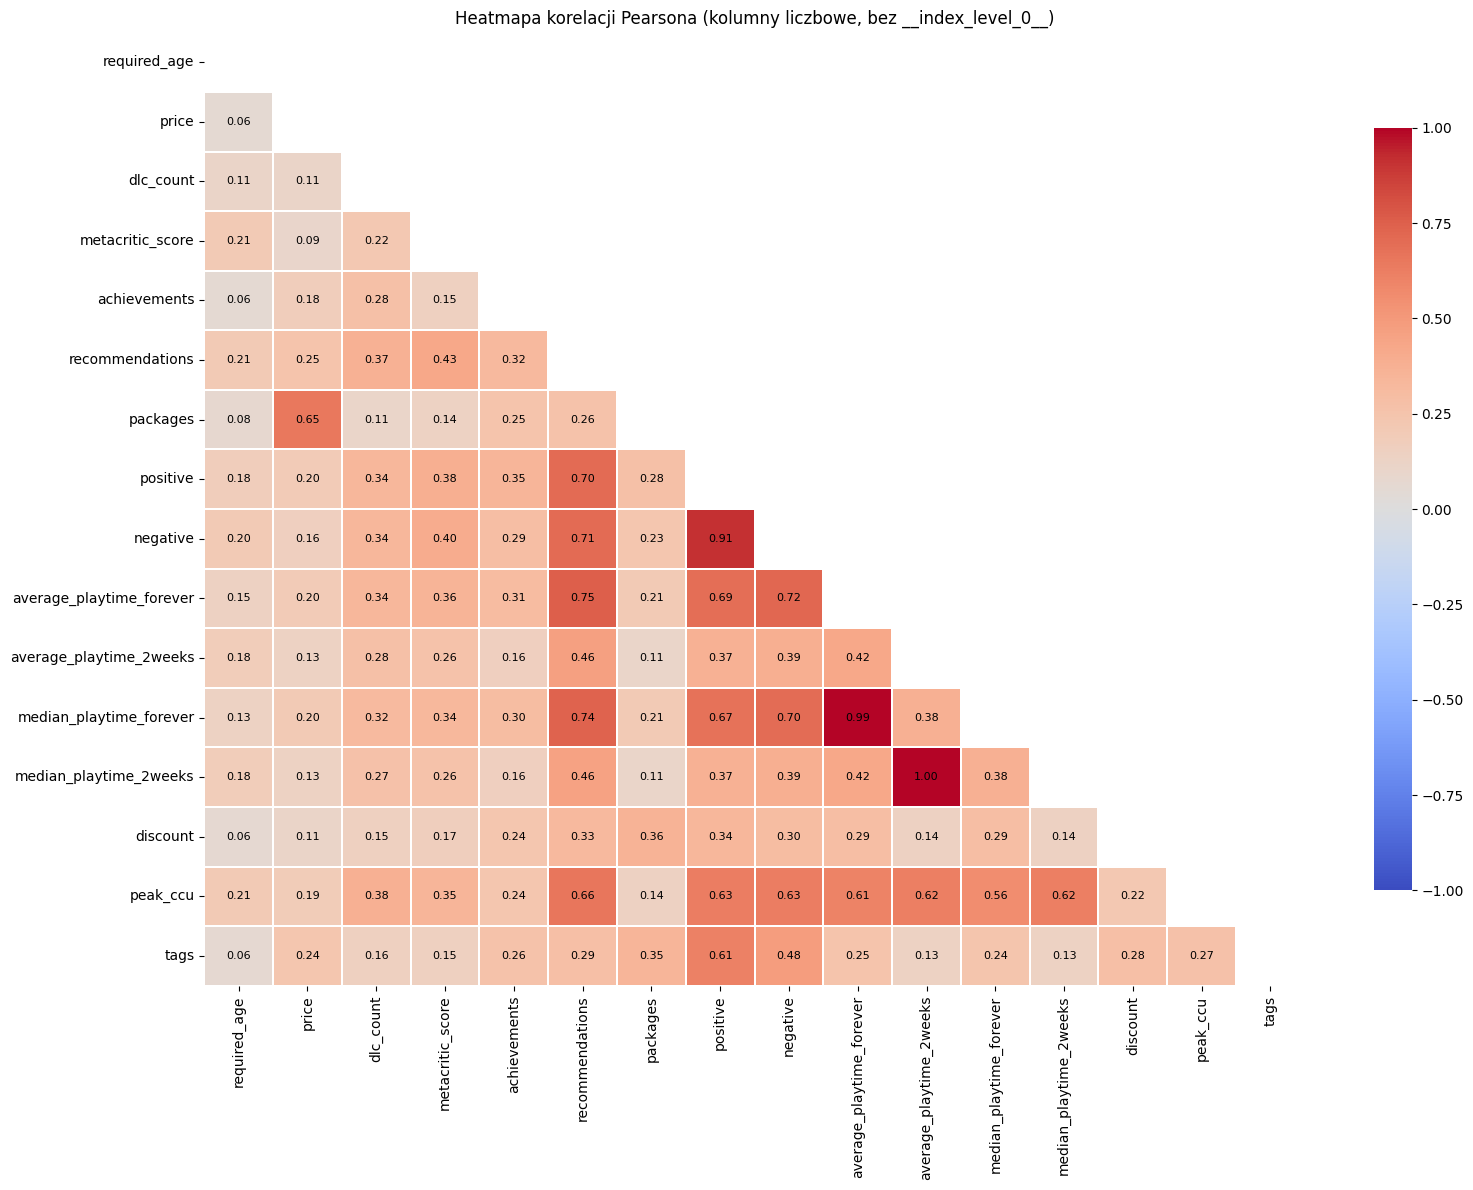

In [21]:
import seaborn as sns
import numpy as np

numeric_cols += ["tags"]
num_df = df.select(numeric_cols).to_pandas()
corr = num_df.corr(method="pearson", numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=False,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
    annot=True,              
    fmt=".2f",               
    annot_kws={"color": "black", "size": 8}
)
plt.title("Heatmapa korelacji Pearsona (kolumny liczbowe, bez __index_level_0__)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Ekonometryczna intuicja nie zawiodła. Wykryto 3 redudentne pary cech:
- average_playtime_2weeks i median_playtime_2weeks (korelacja = 1.0)
- average_playtime_forever i median_playtime_forever (korelacja = 0.99)
- positive i negative (korelacja = 0.91)
Z ciekawości sprawdzę ile danych ze sobą się nie pokrywa jeden do jednego

In [22]:
print("Liczba unikalnych wartości w kolumnach aktywności 2 tygodni:")
print(df[['average_playtime_2weeks','median_playtime_2weeks']].n_unique())
print("Liczba unikalnych wartości w kolumnach aktywności na zawsze:")
print(df[['average_playtime_forever','median_playtime_forever']].n_unique())
print("Liczba unikalnych wartości w kolumnach opinii:")
print(df[['positive','negative']].n_unique())

Liczba unikalnych wartości w kolumnach aktywności 2 tygodni:
2084
Liczba unikalnych wartości w kolumnach aktywności na zawsze:
17524
Liczba unikalnych wartości w kolumnach opinii:
23390


Z powodu ich redundantności usunę kolumny __average_playtime_forever__ i __average_playtime_2weeks__. Są mniej odporne na wartości odstające niż te z medianami. Usunąłbym też kolumnę negatywnych opinii, jednak ta będzie mi później potrzebna do wyznaczania, która z gier jest hitem. Po zrobieniu tej kolumny usunę zarówno pozytywne jak i negatywne, żeby nie doszło do data leakage.

In [23]:
df = df.drop(["average_playtime_2weeks","average_playtime_forever"])

Teraz jeszcze raz spójrzmy na wartości odstające, tym razem każdej kolumny liczbowej.

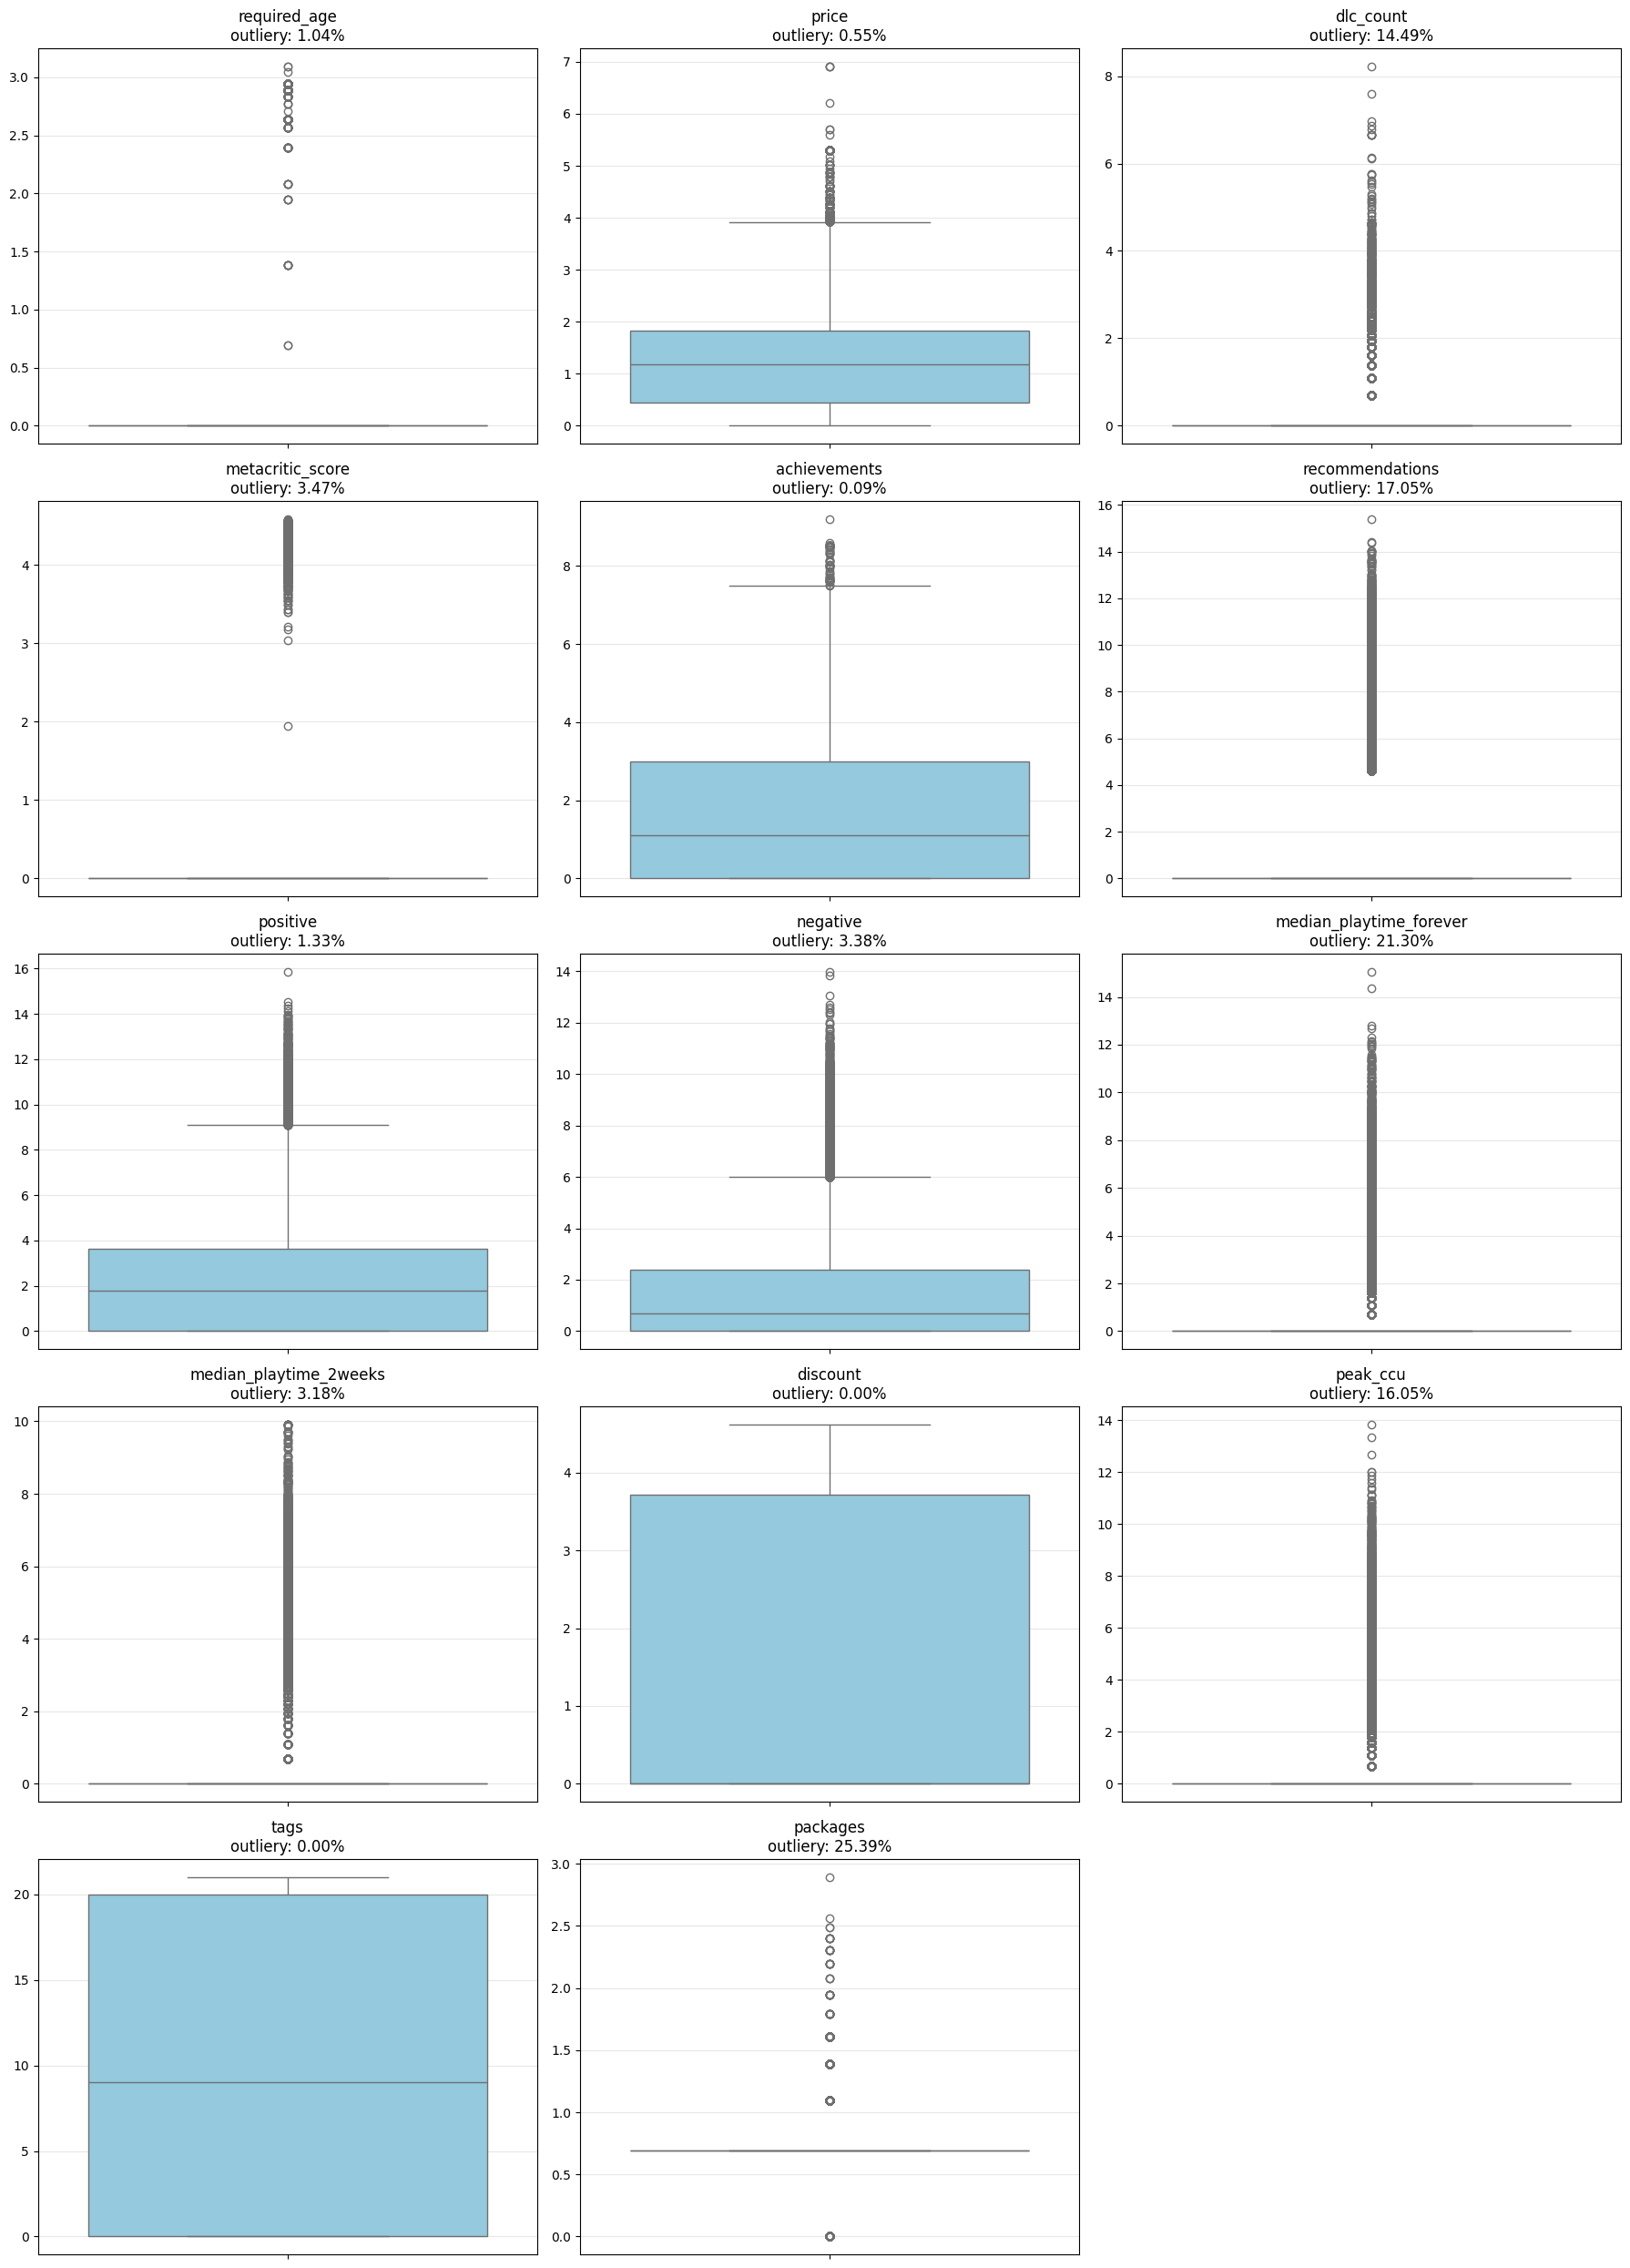

In [24]:
import math

numeric_cols = [c for c in df.select(cs.numeric()).columns if (c != "__index_level_0__" and c != "packages")]
numeric_cols += ["packages"]

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    s = df.get_column(col).drop_nulls()
    values = s.to_numpy()

    if len(values) == 0:
        axes[i].set_title(f"{col}\nbrak danych")
        axes[i].axis("off")
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((s < lower) | (s > upper)).sum()
    outlier_pct = (outlier_count / len(values)) * 100

    sns.boxplot(y=values, ax=axes[i], color="skyblue", showfliers=True)
    axes[i].set_title(f"{col}\noutliery: {outlier_pct:.2f}%")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(True, axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Wykresy w lewej i środkowej kolumnie (poza packages) pokazują, że cechy nie będą raczej zbyt problematyczne dla modeli. Ich liczba wartości odstających jest niewielka (0-3,5%). Problemem są wszystkie cechy z prawej strony powyższego obrazu. Cały boxplot wraz z wąsem nie wychodzi poza 0 i mają dużą liczbę outlierów (14,49-25,4%). Są to cechy ważne, więc usunięcie ich byłoby poważną stratą, a usunięcie wartości odstających byłoby sporą utratą obserwacji.

Żeby rozwiązać ten problem, przetestuję dwie metody:
- podział na 3 progi. Wartość równą 0, małą wartość i dużą.
- winsoryzację górnych wartości do percentyla 99,9

Dokonam podziału dopiero przed trenowaniem modeli, żeby dane były chwilowo bardziej czytelne. Podział będzie miał następujące progi:
1. 0 (dla każdego)
2. 0-1 dla packages; 0-2 dla dlc_count; 0-4 dla peak_ccu i median_playtime_forever; 0-8 dla reccomendation;

### Dane binarne

Sprawdźmy kolumny binarne jak wyglądają.

In [25]:
binary_cols = [col for col, dtype in df.schema.items() if dtype == pl.Boolean]

if not binary_cols:
    print("Brak kolumn binarnych w dataframe.")
else:
    rows = []
    total_rows = df.height

    for col in binary_cols:
        true_count = df.select(pl.col(col).fill_null(False).sum()).item()
        null_count = df.select(pl.col(col).is_null().sum()).item()

        rows.append({
            "column": col,
            "true_pct": round(true_count / total_rows * 100, 2),
            "null_pct": round(null_count / total_rows * 100, 2),
        })

    stats_df = pl.DataFrame(rows)
    display(stats_df)

column,true_pct,null_pct
str,f64,f64
"""windows""",99.96,0.0
"""mac""",17.37,0.0
"""linux""",12.81,0.0


Jak to przyjemnie jest zobaczyć tylko 3 kolumny :)

Widać, że nie ma wartości pustych i w grach dominuje system windows. Sprawdźmy szybko korelacje jak wyglądają, choć nie oczekuję redundancji cech.

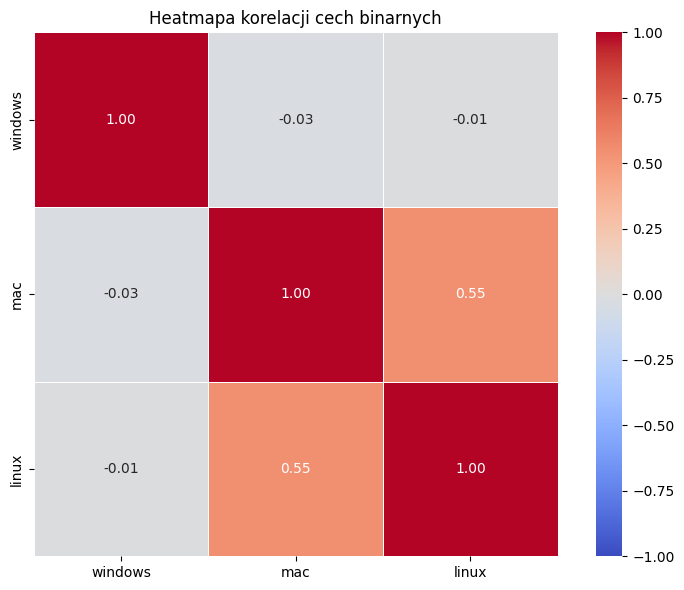

In [26]:
if not binary_cols:
    print("Brak kolumn binarnych w dataframe.")
else:
    binary_df = (
        df.select(binary_cols)
        .fill_null(False)
        .to_pandas()
        .astype("int8")
    )

    corr = binary_df.corr(method="pearson")

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
    )
    plt.title("Heatmapa korelacji cech binarnych")
    plt.tight_layout()
    plt.show()

Tak jak się spodziewałem, każda z cech powinna zostać. Co ciekawe, spora korelacja jest przy systemie linux i mac. Prawdopodobnie przez to, że oba systemy są Unixowe, więc jest nieco ułatwiona konwersja systemów gier.

### Kategorie tekstowe

In [27]:
excluded_cols = {"tags", "packages"}

remaining_cols = [
    c for c in df.columns
    if c not in excluded_cols
    and c not in numeric_cols
    and c not in binary_cols
    and df.schema.get(c) == pl.String
]

rows = []
for col in remaining_cols:
    s = df.get_column(col)
    total = df.height
    null_count = int(s.is_null().sum())
    non_null_count = int(s.drop_nulls().len())

    rows.append({
        "column": col,
        "dtype": str(s.dtype),
        "null_count": null_count,
        "null_pct": round(null_count / total * 100, 2),
        "non_null_count": non_null_count,
    })

remaining_stats = pl.DataFrame(rows).sort("null_pct", descending=True)
display(
    remaining_stats
    .to_pandas()
    .set_index("column")
    .T
)

column,metacritic_url,reviews,notes,website,support_url,support_email,about_the_game,detailed_description,short_description,header_image,name,estimated_owners
dtype,String,String,String,String,String,String,String,String,String,String,String,String
null_count,118355,110541,100153,72935,68419,22247,8449,8420,8309,81,1,0
null_pct,96.53,90.16,81.68,59.48,55.8,18.14,6.89,6.87,6.78,0.07,0.0,0.0
non_null_count,4256,12070,22458,49676,54192,100364,114162,114191,114302,122530,122610,122611


Zacznijmy od czystek kolumn, z których nie widzę opcji wyłuskania sensownych danych do analizy:

In [28]:
df = df.drop(["metacritic_url", "website", "support_url", "support_email", "about_the_game", "short_description", "header_image"])

To teraz spójrzmy jeszcze raz w te dane

In [29]:
excluded_cols = {"tags", "packages"}

remaining_cols = [
    c for c in df.columns
    if c not in excluded_cols
    and c not in numeric_cols
    and c not in binary_cols
    and df.schema.get(c) == pl.String
]

rows = []
for col in remaining_cols:
    s = df.get_column(col)
    total = df.height
    null_count = int(s.is_null().sum())
    non_null_count = int(s.drop_nulls().len())

    rows.append({
        "column": col,
        "dtype": str(s.dtype),
        "null_count": null_count,
        "null_pct": round(null_count / total * 100, 2),
        "non_null_count": non_null_count,
    })

remaining_stats = pl.DataFrame(rows).sort("null_pct", descending=True)
display(
    remaining_stats
    .to_pandas()
    .set_index("column")
    .T
)

column,reviews,notes,detailed_description,name,estimated_owners
dtype,String,String,String,String,String
null_count,110541,100153,8420,1,0
null_pct,90.16,81.68,6.87,0.0,0.0
non_null_count,12070,22458,114191,122610,122611


In [30]:
col = "reviews"

if col in df.columns:
    reviews = (
        df.select(pl.col(col).drop_nulls())
          .get_column(col)
          .to_list()
    )

    if not reviews:
        print("Kolumna istnieje, ale nie ma niepustych wartości.")
    else:
        print("Pierwsze 5 niepustych wartości (pełna treść):\n")
        for i, txt in enumerate(reviews[:5], start=1):
            print(f"[{i}]")
            print(txt)
            print("-" * 80)
else:
    print(f"Brak kolumny: {col}")


Pierwsze 5 niepustych wartości (pełna treść):

[1]
“And this is the very reason why I believe Fantasy General 2: Invasion has not only tremendous staying power, but the potential of a fulfilling future.” 9 – Turn Based Lovers “Graphically, I found the game beautiful, the music even great (the main track has been remastered from the original). The dialogue text and story depth is completely sufficient for me. Even though the balance of the game is not perfect and the level of difficulty is so high that it just cannot be done without reloading and optimizing, I still recommend any lover of turn-based games to buy it. Otherwise, you'll miss one of the most challenging and gripping genre representatives of the year!” 9.0 – Gamersglobal “Like its predecessor, Fantasy General 2 captivates from the first mission and even improves a lot of things from the original: The moral system is more transparent, the missions with their very different goals and many side locations are much more dynamic. 

Dlaczego te kolumny zostały?
- __reviews__ - jest to lista recenzji zawodowych recenzentów gier. Zmienię na liczbę recenzji profesjonalnych, ponieważ ta zmienna w sposób pośredni wskazuje zaangażowanie w PR i marketing gry
- __notes__ - są to dodatkowe uwagi od dewelopera. Zamienię tą kolumnę w informację binarną czy załączył notatki (tylko bardziej zaangażowani zostawiają)
- __detailed_description__ - opis stworzony przez dewelopera. Jeżeli jest bardziej szczegółowy, to autor więcej czasu poświęcił, więc gra może być bardziej dopracowana
- __name__ - z tego samego powodu zostawiam co jest index. Żeby łatwiej się orientować jaką grą jest dana obserwacja
- __estimated_owners__ - są to widełki sprzedanych ilości kopii. Wezmę średnią z tych wartości i zrobię jako kategorię liczbową. Podejrzewam, że znowu będzie wymagać przekształcenia logarytmicznego (log1p)

In [31]:
df = df.with_columns([
    pl.col("reviews")
    .str.count_matches(r"[“\"]")
    .fill_null(0)
    .cast(pl.Int32)
    .alias("reviews"),

    pl.col("notes")
    .is_not_null()
    .cast(pl.Int8)
    .alias("notes"),

    pl.col("detailed_description")
    .str.len_chars()
    .fill_null(0)
    .cast(pl.Int32)
    .alias("detailed_description"),

    ((
        pl.col("estimated_owners").str.split(" - ").list.first().cast(pl.Float64) +
        pl.col("estimated_owners").str.split(" - ").list.last().cast(pl.Float64)
    ) / 2.0)
    .alias("estimated_owners")
])

Describe (klasyczny):


statistic,reviews,notes,detailed_description,estimated_owners
str,f64,f64,f64,f64
"""count""",122611.0,122611.0,122611.0,122611.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.229653,0.183165,1230.050811,85719.674417
"""std""",0.755252,0.386803,1159.284003,1.2897e6
"""min""",0.0,0.0,0.0,0.0
"""25%""",0.0,0.0,604.0,10000.0
"""50%""",0.0,0.0,1013.0,10000.0
"""75%""",0.0,0.0,1598.0,10000.0
"""max""",10.0,1.0,89666.0,1.5e8


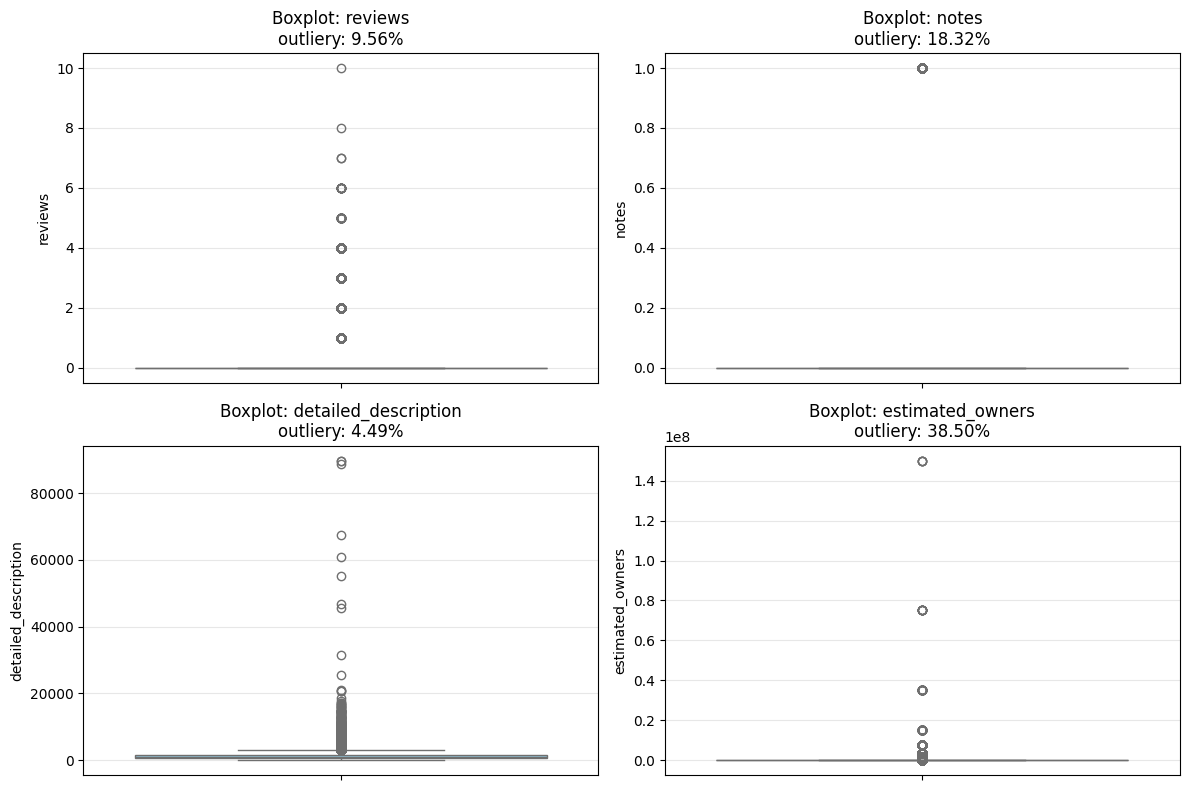

In [32]:
cols = ["reviews", "notes", "detailed_description", "estimated_owners"]

print("Describe (klasyczny):")
display(df.select(cols).describe())

plot_df = df.select(cols).drop_nulls().to_pandas()

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    s = plot_df[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (s < lower) | (s > upper)
    outlier_pct = outlier_mask.mean() * 100

    sns.boxplot(y=s, ax=axes[i], color="skyblue", showfliers=True)
    axes[i].set_title(f"Boxplot: {col}\noutliery: {outlier_pct:.2f}%")
    axes[i].set_xlabel("")
    axes[i].grid(True, axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Dane wyglądają na skośne (poza zmienną binarną), dlatego je zmierzmy

In [33]:
target_cols = ["reviews", "notes", "detailed_description", "estimated_owners"]

rows = []
for col in target_cols:
    s = df.get_column(col).drop_nulls()
    n = s.len()

    if n == 0:
        rows.append({
            "column": col,
            "zero_pct": None,
            "variance": None,
            "skewness": None,
            "normalized_skewness": None,
            "strength": None,
            "p95": None,
            "p99": None,
            "p999": None,
        })
        continue

    raw_skew = s.skew()
    raw_var = s.var()

    if n > 2:
        se_skew = (6 * n / ((n + 1) * (n - 2))) ** 0.5
        normalized_skew = raw_skew / se_skew if se_skew > 0 else None
        strength = (
            "silna" if abs(normalized_skew or 0) > 2 else
            "umiarkowana" if abs(normalized_skew or 0) > 1 else
            "słaba"
        )
    else:
        normalized_skew = None
        strength = None

    rows.append({
        "column": col,
        "zero_pct": float(((s == 0).sum() / n) * 100),
        "variance": float(raw_var) if raw_var is not None else None,
        "skewness": float(raw_skew),
        "normalized_skewness": float(normalized_skew) if normalized_skew is not None else None,
        "strength": strength,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
    })

stats_numeric = (
    pl.DataFrame(rows)
    .sort("zero_pct", descending=True)
)

stats_transposed = (
    stats_numeric
    .select(["column", "zero_pct", "variance", "skewness", "normalized_skewness", "strength", "p95", "p99", "p999"])
    .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
    .pivot(values="wartosc", index="statystyka", columns="column")
)

print("Statystyki kolumn (w tym wariancja i skośność):")
display(stats_transposed)

Statystyki kolumn (w tym wariancja i skośność):


/tmp/ipykernel_509128/593600535.py:57: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
/tmp/ipykernel_509128/593600535.py:58: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="wartosc", index="statystyka", columns="column")


statystyka,reviews,notes,estimated_owners,detailed_description
str,str,str,str,str
"""zero_pct""","""90.4421299883371""","""81.68353573496668""","""17.65012927062009""","""6.867246821247686"""
"""variance""","""0.5704055717123052""","""0.14961657658721808""","""1663280124752.7083""","""1343939.400729525"""
"""skewness""","""3.275886802981439""","""1.6382325508640725""","""71.55160919941028""","""17.381660759179958"""
"""normalized_skewness""","""468.29142724405244""","""234.1870478258244""","""10228.376988821845""","""2484.726492191446"""
"""strength""","""silna""","""silna""","""silna""","""silna"""
"""p95""","""3.0""","""1.0""","""150000.0""","""2978.0"""
"""p99""","""3.0""","""1.0""","""1500000.0""","""4748.0"""
"""p999""","""4.0""","""1.0""","""7500000.0""","""9305.0"""


Tak jak myślałem. Znowu zadziałajmy log1p na nie (z wyłączeniem zmiennej binarnej)

Zastosowano log1p do kolumn: ['reviews', 'detailed_description', 'estimated_owners']
Statystyki po log1p (z wyłączeniem notes):


/tmp/ipykernel_509128/1740150016.py:67: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
/tmp/ipykernel_509128/1740150016.py:68: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="wartosc", index="statystyka", columns="column")


statystyka,reviews,notes,estimated_owners,detailed_description
str,str,str,str,str
"""zero_pct""","""90.4421299883371""","""81.68353573496668""","""17.65012927062009""","""6.867246821247686"""
"""variance""","""0.12960556570831253""","""0.14961657658721808""","""14.982902939630057""","""3.5281855227504058"""
"""skewness""","""3.006818236551773""","""1.6382325508640725""","""-1.366232153249991""","""-2.7292933617206874"""
"""normalized_skewness""","""429.82779569085517""","""234.1870478258244""","""-195.3043079540677""","""-390.15532605237587"""
"""strength""","""silna""","""silna""","""silna""","""silna"""
"""p95""","""1.3862943611198906""","""1.0""","""11.918397239722838""","""7.999342952713282"""
"""p99""","""1.3862943611198906""","""1.0""","""14.220976332738882""","""8.465689348549121"""
"""p999""","""1.6094379124341003""","""1.0""","""15.830413711839864""","""9.138414632404594"""


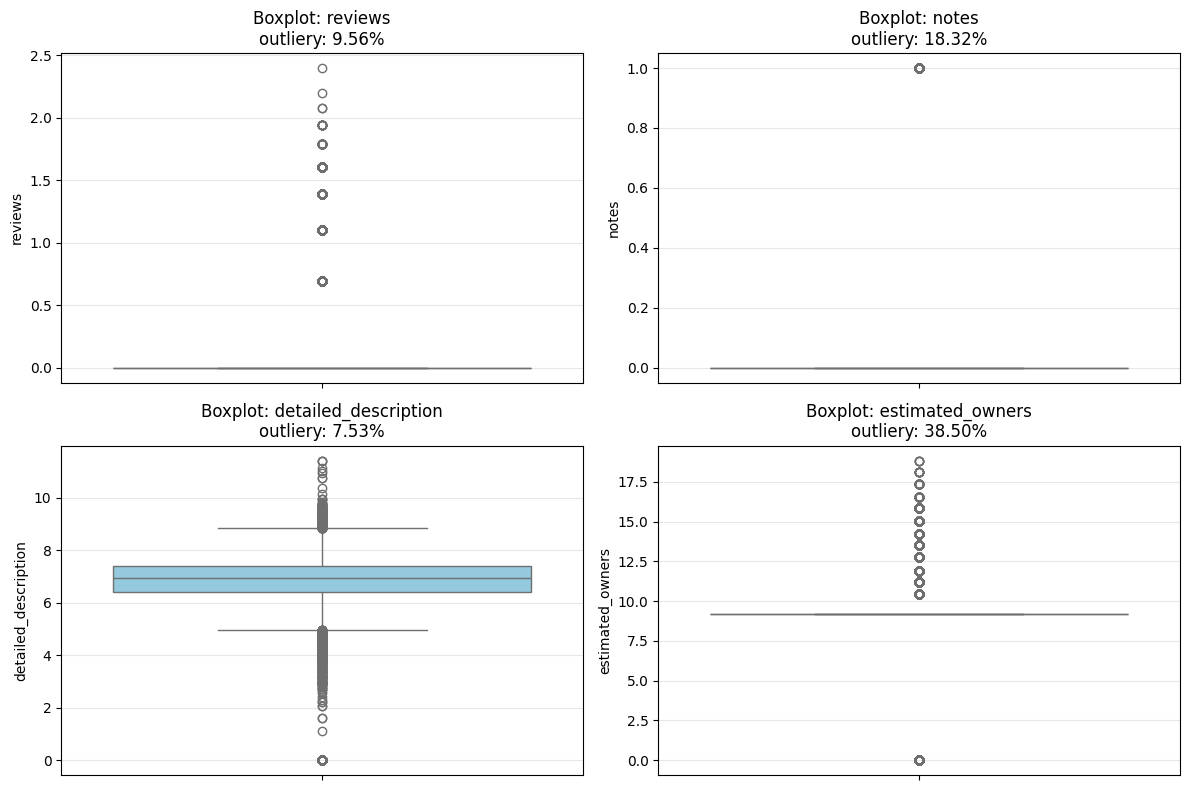

In [34]:
target_cols = ["reviews", "notes", "detailed_description", "estimated_owners"]
log_cols = [c for c in target_cols if c != "notes"]

mins = df.select([pl.col(c).min().alias(c) for c in log_cols]).to_dicts()[0]
invalid_cols = [c for c, v in mins.items() if v is not None and v <= -1]

if invalid_cols:
    print("Nie można zastosować log1p dla kolumn (mają wartości <= -1):", invalid_cols)
else:
    df = df.with_columns([
        pl.col(c).cast(pl.Float64).log1p().alias(c)
        for c in log_cols
    ])
    print(f"Zastosowano log1p do kolumn: {log_cols}")

rows = []
for col in target_cols:
    s = df.get_column(col).drop_nulls()
    n = s.len()

    if n == 0:
        rows.append({
            "column": col,
            "zero_pct": None,
            "variance": None,
            "skewness": None,
            "normalized_skewness": None,
            "strength": None,
            "p95": None,
            "p99": None,
            "p999": None,
        })
        continue

    raw_skew = s.skew()
    raw_var = s.var()

    if n > 2:
        se_skew = (6 * n / ((n + 1) * (n - 2))) ** 0.5
        normalized_skew = raw_skew / se_skew if se_skew > 0 else None
        strength = (
            "silna" if abs(normalized_skew or 0) > 2 else
            "umiarkowana" if abs(normalized_skew or 0) > 1 else
            "słaba"
        )
    else:
        normalized_skew = None
        strength = None

    rows.append({
        "column": col,
        "zero_pct": float(((s == 0).sum() / n) * 100),
        "variance": float(raw_var) if raw_var is not None else None,
        "skewness": float(raw_skew),
        "normalized_skewness": float(normalized_skew) if normalized_skew is not None else None,
        "strength": strength,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
    })

stats_numeric = pl.DataFrame(rows).sort("zero_pct", descending=True)

stats_transposed = (
    stats_numeric
    .select(["column", "zero_pct", "variance", "skewness", "normalized_skewness", "strength", "p95", "p99", "p999"])
    .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
    .pivot(values="wartosc", index="statystyka", columns="column")
)

print("Statystyki po log1p (z wyłączeniem notes):")
display(stats_transposed)

plot_df = df.select(target_cols).drop_nulls().to_pandas()

n_cols = 2
n_rows = math.ceil(len(target_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    s = plot_df[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (s < lower) | (s > upper)
    outlier_pct = outlier_mask.mean() * 100

    sns.boxplot(y=s, ax=axes[i], color="skyblue", showfliers=True)
    axes[i].set_title(f"Boxplot: {col}\noutliery: {outlier_pct:.2f}%")
    axes[i].set_xlabel("")
    axes[i].grid(True, axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Pierwszy raz pojawiła się większa liczba outlierów po logarytmowaniu parametrów liczbowych w detailed_description. No cóż, szkoda, ale nadal spadek wariancji i poprawa skośności jest tego warta. (Tak, wcześniej też sprawdzałem wariancje i skośność, nawet jak o tym nie pisałem.)

### Pozostałe kategorie

In [35]:
excluded_cols = {"tags", "packages", "__index_level_0__", "detailed_description", "reviews", "notes", "estimated_owners"}

remaining_cols = [
    c for c in df.columns
    if c not in excluded_cols
    and c not in numeric_cols
    and c not in binary_cols
    and df.schema.get(c) != pl.String
]

rows = []
for col in remaining_cols:
    s = df.get_column(col)
    total = df.height
    null_count = int(s.is_null().sum())
    non_null_count = int(s.drop_nulls().len())

    rows.append({
        "column": col,
        "dtype": str(s.dtype),
        "null_count": null_count,
        "null_pct": round(null_count / total * 100, 2),
        "non_null_count": non_null_count,
    })

remaining_stats = pl.DataFrame(rows).sort("null_pct", descending=True)
display(
    remaining_stats
    .to_pandas()
    .set_index("column")
    .T
)

column,full_audio_languages,categories,publishers,developers,genres,supported_languages,screenshots,release_date
dtype,List(String),List(String),List(String),List(String),List(String),List(String),List(String),"Datetime(time_unit='ns', time_zone=None)"
null_count,72730,8953,8827,8431,8413,8380,6018,0
null_pct,59.32,7.3,7.2,6.88,6.86,6.83,4.91,0.0
non_null_count,49881,113658,113784,114180,114198,114231,116593,122611


Ze względu na upływający czas, muszę nieco przyspieszyć pracę, dlatego będę w tej zakładce bardziej surowy wobec danych.
- opcje językowe mogą być przydatne ponieważ mocno wynikają z budżetu przeznaczonego na grę, więc warto to wypisać chociaż ich liczbę. Prawdopodobnie przydałyby się informacje o chińskim i angielskim, ale dla uproszczenia i przyspieszenia pracy zignoruję ten fakt.
- deweloperów i wydawców jest zbyt dużo, żeby się tym rozdrabniać. Tak samo gatunków i kategori, więc po prostu usunę. Podejrzewam, że gra singleplayer lub multiplayer może mieć znaczenie, ale raczej nie będzie to czynnikiem decydującym.
- screenshoty nie mają sensu w analizie danych. Może ich liczba by coś pokazała, ale już i tak mam za dużo wymiarów więc szkoda zaśmiecać dataset. Usunę.
- data premiery ma sens, ponieważ starsze gry miały więcej czasu na zebranie recenzji i opinii, co później będzie przekładało się czy jest hitem. Więc tą zmienną uproszczę do samego roku.

In [36]:
df = df.drop(["categories", "publishers", "developers", "genres", "screenshots"])

In [37]:
df = df.with_columns([
    pl.col("supported_languages")
    .list.len()
    .fill_null(0)
    .cast(pl.Int32)
    .alias("supported_languages"),

    pl.col("full_audio_languages")
    .list.len()
    .fill_null(0)
    .cast(pl.Int32)
    .alias("full_audio_languages"),

    pl.col("release_date")
    .dt.year()
    .alias("release_date")
])

print(df.select(["supported_languages", "full_audio_languages", "release_date"]).head(5))

shape: (5, 3)
┌─────────────────────┬──────────────────────┬──────────────┐
│ supported_languages ┆ full_audio_languages ┆ release_date │
│ ---                 ┆ ---                  ┆ ---          │
│ i32                 ┆ i32                  ┆ i32          │
╞═════════════════════╪══════════════════════╪══════════════╡
│ 0                   ┆ 0                    ┆ 2023         │
│ 1                   ┆ 0                    ┆ 2016         │
│ 4                   ┆ 0                    ┆ 2019         │
│ 1                   ┆ 1                    ┆ 2024         │
│ 1                   ┆ 1                    ┆ 2025         │
└─────────────────────┴──────────────────────┴──────────────┘


Describe (klasyczny):


statistic,supported_languages,full_audio_languages,release_date
str,f64,f64,f64
"""count""",122611.0,122611.0,122611.0
"""null_count""",0.0,0.0,0.0
"""mean""",5.212828,1.84702,2021.53266
"""std""",13.50572,10.056078,3.274996
"""min""",0.0,0.0,1997.0
"""25%""",1.0,0.0,2019.0
"""50%""",1.0,0.0,2022.0
"""75%""",4.0,1.0,2024.0
"""max""",103.0,103.0,2026.0


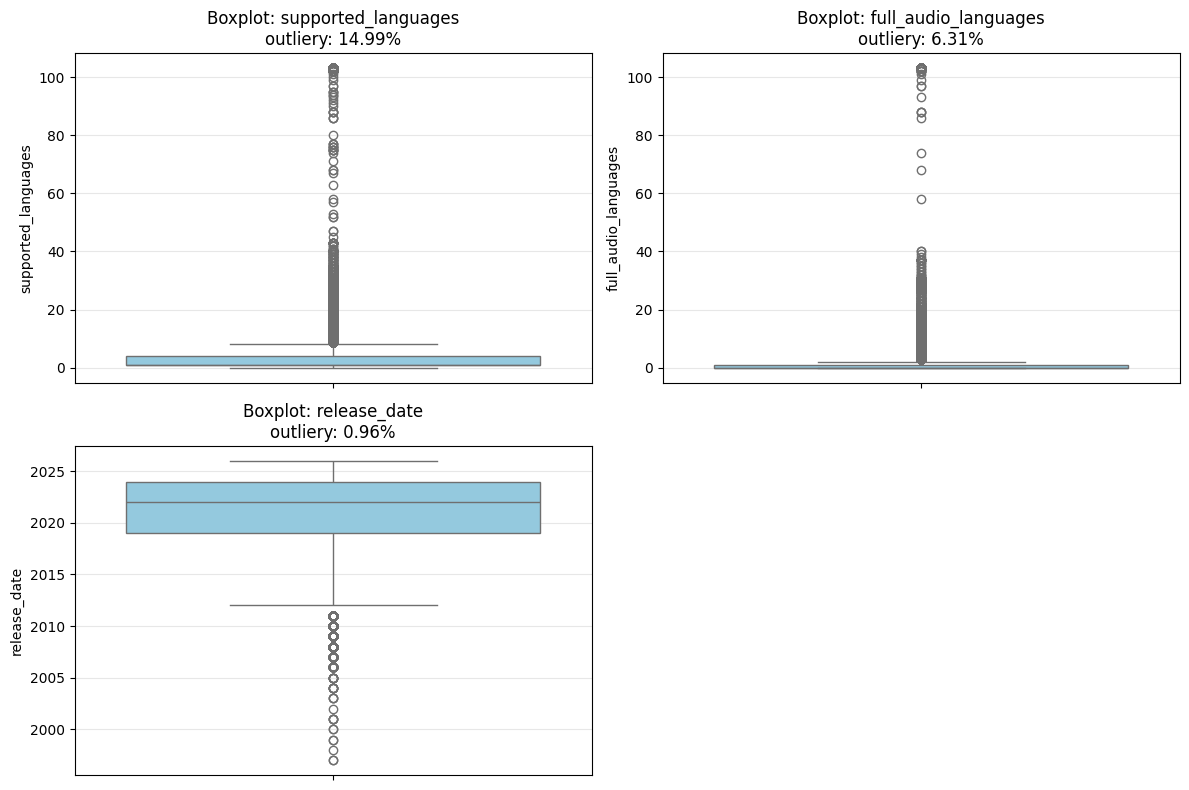

In [38]:
cols = ["supported_languages", "full_audio_languages", "release_date"]

print("Describe (klasyczny):")
display(df.select(cols).describe())

plot_df = df.select(cols).drop_nulls().to_pandas()

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    s = plot_df[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (s < lower) | (s > upper)
    outlier_pct = outlier_mask.mean() * 100

    sns.boxplot(y=s, ax=axes[i], color="skyblue", showfliers=True)
    axes[i].set_title(f"Boxplot: {col}\noutliery: {outlier_pct:.2f}%")
    axes[i].set_xlabel("")
    axes[i].grid(True, axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [39]:
target_cols = ["supported_languages", "full_audio_languages", "release_date"]

rows = []
for col in target_cols:
    s = df.get_column(col).drop_nulls()
    n = s.len()

    if n == 0:
        rows.append({
            "column": col,
            "zero_pct": None,
            "variance": None,
            "skewness": None,
            "normalized_skewness": None,
            "strength": None,
            "p95": None,
            "p99": None,
            "p999": None,
        })
        continue

    raw_skew = s.skew()
    raw_var = s.var()

    if n > 2:
        se_skew = (6 * n / ((n + 1) * (n - 2))) ** 0.5
        normalized_skew = raw_skew / se_skew if se_skew > 0 else None
        strength = (
            "silna" if abs(normalized_skew or 0) > 2 else
            "umiarkowana" if abs(normalized_skew or 0) > 1 else
            "słaba"
        )
    else:
        normalized_skew = None
        strength = None

    rows.append({
        "column": col,
        "zero_pct": float(((s == 0).sum() / n) * 100),
        "variance": float(raw_var) if raw_var is not None else None,
        "skewness": float(raw_skew),
        "normalized_skewness": float(normalized_skew) if normalized_skew is not None else None,
        "strength": strength,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
    })

stats_numeric = (
    pl.DataFrame(rows)
    .sort("zero_pct", descending=True)
)

stats_transposed = (
    stats_numeric
    .select(["column", "zero_pct", "variance", "skewness", "normalized_skewness", "strength", "p95", "p99", "p999"])
    .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
    .pivot(values="wartosc", index="statystyka", columns="column")
)

print("Statystyki kolumn (w tym wariancja i skośność):")
display(stats_transposed)

Statystyki kolumn (w tym wariancja i skośność):


/tmp/ipykernel_509128/1320816496.py:57: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
/tmp/ipykernel_509128/1320816496.py:58: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="wartosc", index="statystyka", columns="column")


statystyka,full_audio_languages,supported_languages,release_date
str,str,str,str
"""zero_pct""","""59.31767949042093""","""6.834623320909216""","""0.0"""
"""variance""","""101.12470074911275""","""182.4044634598574""","""10.725601192577948"""
"""skewness""","""9.428070433845779""","""6.145186428593936""","""-1.096093068382832"""
"""normalized_skewness""","""1347.7524789943445""","""878.4607944047268""","""-156.6876446762918"""
"""strength""","""silna""","""silna""","""silna"""
"""p95""","""3.0""","""16.0""","""2025.0"""
"""p99""","""29.0""","""103.0""","""2025.0"""
"""p999""","""103.0""","""103.0""","""2025.0"""


Widać znaczącą skośność. Jedynie w przypadku dat skośność jest w drugą stronę, co oznacza że w późniejszych latach wydaje się więcej gier niż we wcześniejszych. Jednak wariancja w tym przypadku jest wyjątkowo mała i skośność choć ogólnie gigantyczna, to w porównaniu do pozostałych i tak mała. Z tego powodu zostawię stan obecny, jednak pewnie powinienem to przekształcić i znów zlogarytmizować. (Np. wymnażając przez -1 powiększając by minimum było równe zero i taki rezultat zlogarytmizować i porównać przed i po czy jest dobrze.)

Zastosowano log1p do kolumn: ['supported_languages', 'full_audio_languages']
Statystyki po log1p (z wyłączeniem notes):


/tmp/ipykernel_509128/1122215678.py:67: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
/tmp/ipykernel_509128/1122215678.py:68: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="wartosc", index="statystyka", columns="column")


statystyka,full_audio_languages,supported_languages
str,str,str
"""zero_pct""","""59.31767949042093""","""6.834623320909216"""
"""variance""","""0.49345463642939114""","""0.7934258925413188"""
"""skewness""","""2.8605406536013978""","""1.4455081057240557"""
"""normalized_skewness""","""408.9172629974489""","""206.6368878516466"""
"""strength""","""silna""","""silna"""
"""p95""","""1.3862943611198906""","""2.833213344056216"""
"""p99""","""3.4011973816621555""","""4.6443908991413725"""
"""p999""","""4.6443908991413725""","""4.6443908991413725"""


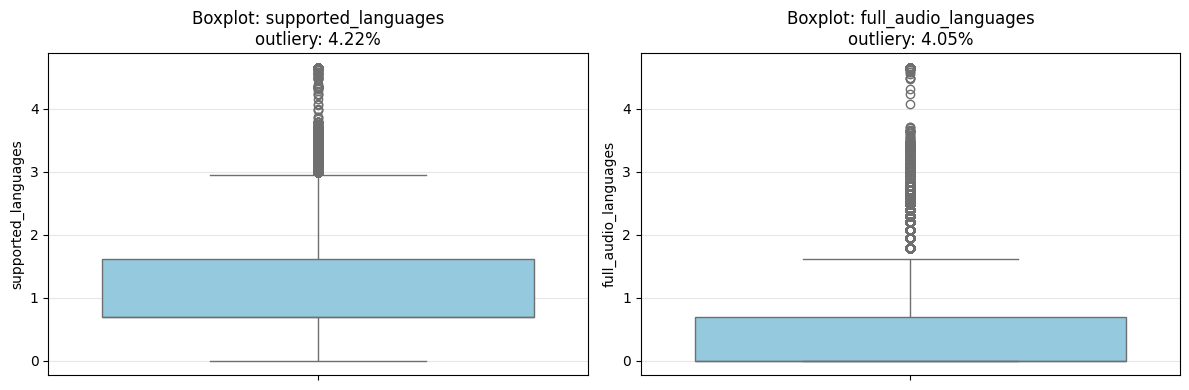

In [40]:
target_cols = ["supported_languages", "full_audio_languages"]
log_cols = [c for c in target_cols if c != "notes"]

mins = df.select([pl.col(c).min().alias(c) for c in log_cols]).to_dicts()[0]
invalid_cols = [c for c, v in mins.items() if v is not None and v <= -1]

if invalid_cols:
    print("Nie można zastosować log1p dla kolumn (mają wartości <= -1):", invalid_cols)
else:
    df = df.with_columns([
        pl.col(c).cast(pl.Float64).log1p().alias(c)
        for c in log_cols
    ])
    print(f"Zastosowano log1p do kolumn: {log_cols}")

rows = []
for col in target_cols:
    s = df.get_column(col).drop_nulls()
    n = s.len()

    if n == 0:
        rows.append({
            "column": col,
            "zero_pct": None,
            "variance": None,
            "skewness": None,
            "normalized_skewness": None,
            "strength": None,
            "p95": None,
            "p99": None,
            "p999": None,
        })
        continue

    raw_skew = s.skew()
    raw_var = s.var()

    if n > 2:
        se_skew = (6 * n / ((n + 1) * (n - 2))) ** 0.5
        normalized_skew = raw_skew / se_skew if se_skew > 0 else None
        strength = (
            "silna" if abs(normalized_skew or 0) > 2 else
            "umiarkowana" if abs(normalized_skew or 0) > 1 else
            "słaba"
        )
    else:
        normalized_skew = None
        strength = None

    rows.append({
        "column": col,
        "zero_pct": float(((s == 0).sum() / n) * 100),
        "variance": float(raw_var) if raw_var is not None else None,
        "skewness": float(raw_skew),
        "normalized_skewness": float(normalized_skew) if normalized_skew is not None else None,
        "strength": strength,
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "p999": float(s.quantile(0.999)),
    })

stats_numeric = pl.DataFrame(rows).sort("zero_pct", descending=True)

stats_transposed = (
    stats_numeric
    .select(["column", "zero_pct", "variance", "skewness", "normalized_skewness", "strength", "p95", "p99", "p999"])
    .melt(id_vars="column", variable_name="statystyka", value_name="wartosc")
    .pivot(values="wartosc", index="statystyka", columns="column")
)

print("Statystyki po log1p (z wyłączeniem notes):")
display(stats_transposed)

plot_df = df.select(target_cols).drop_nulls().to_pandas()

n_cols = 2
n_rows = math.ceil(len(target_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    s = plot_df[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (s < lower) | (s > upper)
    outlier_pct = outlier_mask.mean() * 100

    sns.boxplot(y=s, ax=axes[i], color="skyblue", showfliers=True)
    axes[i].set_title(f"Boxplot: {col}\noutliery: {outlier_pct:.2f}%")
    axes[i].set_xlabel("")
    axes[i].grid(True, axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Widać znaczącą poprawę struktury danych, jeszcze szybki rzut okiem na korelacje wszystkich cech liczbowych, usunięcie potencjalnych duplikatów i można zakończyć eksplorację dancyh.

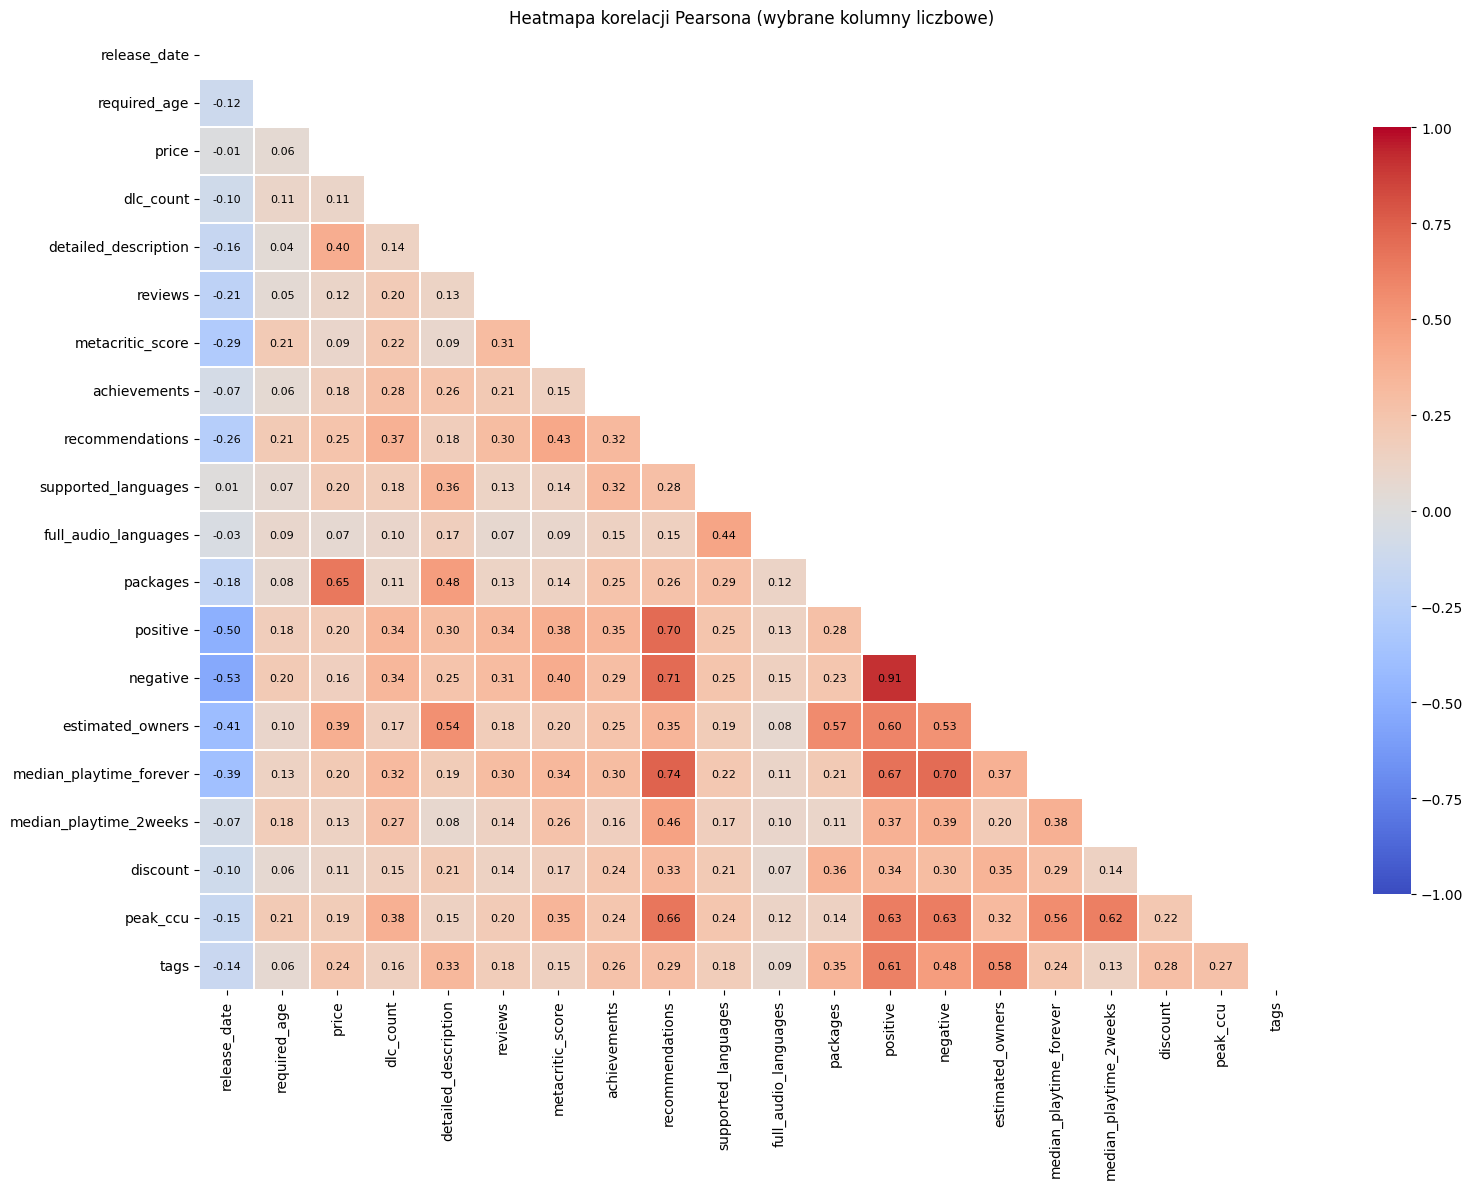

In [41]:
cols_for_corr = [
    c for c in df.select(cs.numeric()).columns 
    if c not in ["notes", "__index_level_0__"]
]

num_df = df.select(cols_for_corr).to_pandas()
corr = num_df.corr(method="pearson")
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=False,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
    annot=True,              
    fmt=".2f",               
    annot_kws={"color": "black", "size": 8}
)

plt.title("Heatmapa korelacji Pearsona (wybrane kolumny liczbowe)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
subset_cols = [c for c in df.columns if c != "__index_level_0__"]

initial_count = df.height
df = df.unique(subset=subset_cols)
final_count = df.height

print(f"Usunięto {initial_count - final_count} duplikatów.")
print(f"Liczba wierszy po usunięciu: {final_count}")

Usunięto 14 duplikatów.
Liczba wierszy po usunięciu: 122597


## Ciekawa nieoczywista zależność

Jest to zadanie niezwykle trudne, ponieważ dla każdego coś innego może być nieoczywiste.

Jednego może zaskoczyć wysoka korelacja między grami powstającymi na linuxie i macos. Niektórzy tłumaczą to tym, że bazują na unixie, ja bardziej interpretuję biznesowo. Wg mnie liczba gier na różnych platformach zależy od popularności platform, dlatego ponad 99% gier jest na windowsie (ma ponad 70% rynku). Reszta systemów jest niszowa i z tego powodu na macos powstało trochę ponad 17% gier z biblioteki steam (przy około 15% rynku systemów), i niecałe 13% na linuxy (przy około 4% rynku). Jeżeli jakiś producent już rozważał wejście na inne systemy niż windows to kierował się udziałem w rynku systemów, a jeżeli zależało mu na mniejszych rynkach to raczej był większym producentem i przy okazji zawalczył o 3-ci w popularności system.

Inną zależnością niewidoczną na pierwszy rzut oka (którą zrealizuję wramach podpunktu b) jest wzrost częstotliwości recenzowania droższych gier przy dużej liczbie sprzedanych kopii gry. 

Tabela podsumowujaca (mediana w grupach):


price_tier,games_count,median_total_reviews,median_review_ratio
str,u32,f64,f64
"""1. Darmowe (0$)""",279,20311.0,0.007302
"""2. Bardzo tanie (0-5$)""",520,23186.5,0.011928
"""3. Srednie (5-20$)""",458,37457.5,0.017301
"""4. Drogie (>20$)""",97,64859.0,0.021318


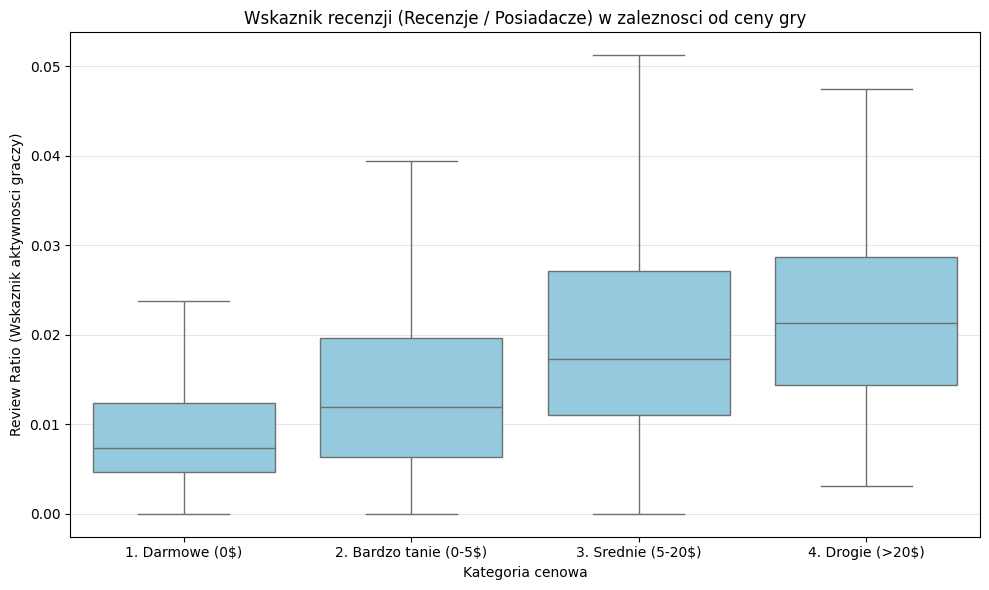

In [43]:
threshold_owners = math.log1p(1_000_000)
threshold_price_free = math.log1p(0)
threshold_price_cheap = math.log1p(5.0)
threshold_price_medium = math.log1p(20.0)

df_analysis = df.filter(
    (pl.col("estimated_owners") >= threshold_owners) &
    (pl.col("price").is_not_null()) &
    (pl.col("positive").is_not_null()) &
    (pl.col("negative").is_not_null())
).with_columns([
    ((pl.col("positive").exp() - 1) + (pl.col("negative").exp() - 1)).alias("total_user_reviews")
]).with_columns([
    (pl.col("total_user_reviews") / (pl.col("estimated_owners").exp() - 1)).alias("review_ratio")
]).with_columns([
    pl.when(pl.col("price") <= threshold_price_free).then(pl.lit("1. Darmowe (0$)"))
    .when(pl.col("price") <= threshold_price_cheap).then(pl.lit("2. Bardzo tanie (0-5$)"))
    .when(pl.col("price") <= threshold_price_medium).then(pl.lit("3. Srednie (5-20$)"))
    .otherwise(pl.lit("4. Drogie (>20$)"))
    .alias("price_tier")
])

stats_df = df_analysis.group_by("price_tier").agg([
    pl.len().alias("games_count"),
    pl.col("total_user_reviews").median().alias("median_total_reviews"),
    pl.col("review_ratio").median().alias("median_review_ratio")
]).sort("price_tier")

print("Tabela podsumowujaca (mediana w grupach):")
display(stats_df)

plot_df = df_analysis.select(["price_tier", "review_ratio"]).to_pandas()
category_order = ["1. Darmowe (0$)", "2. Bardzo tanie (0-5$)", "3. Srednie (5-20$)", "4. Drogie (>20$)"]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df, 
    x="price_tier", 
    y="review_ratio", 
    order=category_order,
    color="skyblue", 
    showfliers=False 
)

plt.title("Wskaznik recenzji (Recenzje / Posiadacze) w zaleznosci od ceny gry")
plt.xlabel("Kategoria cenowa")
plt.ylabel("Review Ratio (Wskaznik aktywnosci graczy)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Przy tak silnych skośnościach jakie wcześniej widziałem, nawet mi się nie chce mierzyć skośności w tych grupach. Nie wierzę w to, żeby były spełnione warunki testów parametrycznych jak ANOVA czy t-studenta, dlatego zastosuję Kruskala-Wallisa i dopieczętuję wynik testem Manna-Whitneya. 

Ze względu, że nie znam techniki zbierania tych danych, celem spełnienia warunków koniecznych wylosuję równe próbki po 80 obserwacji do testu. Najmniej losowe będzie najmniejsza grupa, czyli najdroższe gry z 97 obserwacjami, ale będzie raczej wystarczająca mimo wszystko.

In [44]:
import scipy.stats as stats

sample_size = 80
random_seed = 123


free_sample = (
    df_analysis.filter(pl.col("price_tier") == "1. Darmowe (0$)")
    .sample(n=sample_size, seed=random_seed)
    .get_column("review_ratio").drop_nulls().to_numpy()
)

cheap_sample = (
    df_analysis.filter(pl.col("price_tier") == "2. Bardzo tanie (0-5$)")
    .sample(n=sample_size, seed=random_seed)
    .get_column("review_ratio").drop_nulls().to_numpy()
)

medium_sample = (
    df_analysis.filter(pl.col("price_tier") == "3. Srednie (5-20$)")
    .sample(n=sample_size, seed=random_seed)
    .get_column("review_ratio").drop_nulls().to_numpy()
)

expensive_sample = (
    df_analysis.filter(pl.col("price_tier") == "4. Drogie (>20$)")
    .sample(n=sample_size, seed=random_seed)
    .get_column("review_ratio").drop_nulls().to_numpy()
)

kw_stat, kw_p_value = stats.kruskal(free_sample, cheap_sample, medium_sample, expensive_sample)

print("--- TEST 1: Kruskal-Wallis (Porownanie wszystkich 4 grup) ---")
print(f"Statystyka H: {kw_stat:.4f}")
print(f"P-value: {kw_p_value:.4e}")
if kw_p_value < 0.05:
    print("Wynik: ODRZUCAMY hipoteze zerowa. Grupy istotnie roznia sie miedzy soba.\n")
else:
    print("Wynik: BRAK PODSTAW do odrzucenia hipotezy zerowej.\n")


mw_stat, mw_p_value = stats.mannwhitneyu(free_sample, expensive_sample, alternative='less')

print("--- TEST 2: Mann-Whitney U (1. Darmowe vs 4. Drogie) ---")
print(f"Statystyka U: {mw_stat:.4f}")
print(f"P-value: {mw_p_value:.4e}")
if mw_p_value < 0.05:
    print("Wynik: ODRZUCAMY hipoteze zerowa. Wskaznik dla gier darmowych jest STATYSTYCZNIE NIZSZY niz dla gier drogich.")
else:
    print("Wynik: BRAK PODSTAW do stwierdzenia, ze darmowe maja nizszy wskaznik.")

--- TEST 1: Kruskal-Wallis (Porownanie wszystkich 4 grup) ---
Statystyka H: 70.5412
P-value: 3.2686e-15
Wynik: ODRZUCAMY hipoteze zerowa. Grupy istotnie roznia sie miedzy soba.

--- TEST 2: Mann-Whitney U (1. Darmowe vs 4. Drogie) ---
Statystyka U: 1032.0000
P-value: 6.9727e-14
Wynik: ODRZUCAMY hipoteze zerowa. Wskaznik dla gier darmowych jest STATYSTYCZNIE NIZSZY niz dla gier drogich.


Co to oznacza dla wydawców gier?
- Sporo gier sprzedaje się przez jakieś internetowe kasyna (które oczywiście siebie nie nazwą kasynami) gdzie losowany jest klucz do gry np. w formie skrzynek. Co prawda wydawca sprzeda dzięki temu sporo gier, ale w ten sposób gry nie będą ogrywane ani recenzjonowane (co w brew pozorom może być dla nich korzystne).
- Ludzie częściej kupują tanie gry których później nigdy nie uruchamiają.
- Ludzie wydając więcej pieniędzy na grę, bardziej się w nią angażują i chętniej ją skrytykują lub pochwalą.

## Model ML

### Finalizacja korekcji danych pod ML

Zgodnie z wcześniejszą analizą utworzę dwa pliki .parquet, które posłużą mi do trenowania modeli. Jeden z klasyfikacją kategoryczną dla 3 cech, a drugą z ograniczeniem odgórnym wartości odstających. Jednak zacznijmy od rzeczy neutralnych dla każdej wersji pliku:

Wyliczenie czy jakaś gra jest hitem

In [45]:
df = df.with_columns([
    (
        ((pl.col("positive").exp() - 1) >= 1000) & 
        ((pl.col("positive").exp() - 1) / ((pl.col("positive").exp() - 1) + (pl.col("negative").exp() - 1)) >= 0.8)
    )
    .fill_null(False)
    .alias("is_hit")
])

hit_pct = df.select(pl.col("is_hit").mean() * 100).item()
print(f"Hity stanowią {hit_pct:.2f}% całego zbioru danych.")

Hity stanowią 3.85% całego zbioru danych.


Dana zgadza się z wytycznymi zadania, dlatego przechodzę do usuwania niepotrzebnych kolumn.

In [46]:
df = df.drop(["positive", "negative", "name", "__index_level_0__"])

In [47]:
print("\nPodstawowe informacje o zbiorze danych (Schema):")
schema = df.schema
print(schema)


Podstawowe informacje o zbiorze danych (Schema):
Schema({'release_date': Int32, 'required_age': Float64, 'price': Float64, 'dlc_count': Float64, 'detailed_description': Float64, 'reviews': Float64, 'windows': Boolean, 'mac': Boolean, 'linux': Boolean, 'metacritic_score': Float64, 'achievements': Float64, 'recommendations': Float64, 'notes': Int8, 'supported_languages': Float64, 'full_audio_languages': Float64, 'packages': Float64, 'estimated_owners': Float64, 'median_playtime_forever': Float64, 'median_playtime_2weeks': Float64, 'discount': Float64, 'peak_ccu': Float64, 'tags': Int32, 'is_hit': Boolean})


Skoro już nie ma kiepskich typów danych, to zrzutujmy binarne na int8 dla łątwiejszej później interpretowalności drzew.

In [48]:
boolean_cols = [col for col, dtype in df.schema.items() if dtype == pl.Boolean]

df = df.with_columns([
    pl.col(col).cast(pl.Int8) for col in boolean_cols
])

print("Nowy schemat po rzutowaniu:")
print(df.select(boolean_cols).schema)

Nowy schemat po rzutowaniu:
Schema({'windows': Int8, 'mac': Int8, 'linux': Int8, 'is_hit': Int8})


To teraz zapisanie dwóch osobnych parquetów jako `gamesV1.parquet` i `gamesV2.parquet`

In [49]:
new_parquet_path = './archive/gamesV1.parquet'
df.write_parquet(new_parquet_path)

cols_to_winsorize = ["packages", "dlc_count", "peak_ccu", "median_playtime_forever", "recommendations"]
winsorize_exprs = []
for col in cols_to_winsorize:
    p999 = df.get_column(col).quantile(0.999)
    winsorize_exprs.append(
        pl.when(pl.col(col) > p999)
        .then(p999)
        .otherwise(pl.col(col))
        .alias(col)
    )

df = df.with_columns(winsorize_exprs)

df.write_parquet('./archive/gamesV2.parquet')
df = pl.read_parquet(new_parquet_path)

thresholds = {
    "packages": 1.0,
    "dlc_count": 2.0,
    "peak_ccu": 4.0,
    "median_playtime_forever": 4.0,
    "recommendations": 8.0
}

categorization_exprs = []
for col, upper_bound in thresholds.items():
    categorization_exprs.append(
        (pl.col(col) == 0).cast(pl.Int8).alias(f"{col}_is_zero")
    )
    categorization_exprs.append(
        ((pl.col(col) > 0) & (pl.col(col) <= upper_bound)).cast(pl.Int8).alias(f"{col}_small_value")
    )

df = df.with_columns(categorization_exprs)
df.write_parquet(new_parquet_path)

### Porównanie modeli ML

Ze względu na masę wartości odstających, spore wariancje i skośności zacznę od stosowania metod statystycznych odpornych na 

## Co poprawiłbym
Zdecydowanie bardziej bym potestował i pobadał inne metody normalizacji cech, ponieważ widziałem wielokrotnie że ten logarytm poprawia, ale jest raczej średni i coś innego pewnie lepiej by pasowało. No ale brakowało czasu.